In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from ydata_profiling import ProfileReport

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker as ticker

# Preprocessing Libraries
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Model Selection & Evaluation
from sklearn.model_selection import train_test_split, KFold, learning_curve, cross_val_score, GridSearchCV, RandomizedSearchCV

# Machine Learning Models
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

# Pipeline
from sklearn.pipeline import make_pipeline

# Metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, silhouette_score,
    confusion_matrix, roc_curve, auc, precision_score, recall_score,
    f1_score, classification_report, precision_recall_curve, accuracy_score
)
from sklearn.metrics import ConfusionMatrixDisplay

# Statistics & Diagnostic Tests
from scipy import stats
from scipy.stats import kstest, norm, pearsonr, shapiro, levene, kruskal
from statsmodels.api import OLS, add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_rainbow
import statsmodels.api as sm

# Saving Models
import joblib
from joblib import dump
import os

# **DETECTION FAUX BILLETS**

Nous intervenons en tant que Senior Data Analyst auprès de l'**Organisation nationale de lutte contre le faux-monnayage (ONCFM)**.  
Notre mission est de mettre à disposition des équipes une application de machine learning qui leur permettra d’identifier les faux billets en euros pour lutter contre la contrefaçon.  
Elle devra faire une prédiction sur la nature des billets (vrai billet ou faux billet).

# Chargement des données

In [2]:
# Charger le fichier CSV avec les bons paramètres
file_path = r"C:\Users\Willkommen\OneDrive\Docs privés\HERVE\FORMATION\DATA_ANALYST_OC\PROJET_12\DATA\billets.csv"

df = pd.read_csv(file_path, sep=";", encoding="utf-8")

# Analyse exploratoire des données

In [8]:
# Créez le rapport à partir de votre DataFrame 'df'
profile = ProfileReport(df, title="Rapport d'analyse des données", explorative=True)

# Affichez le rapport dans votre notebook
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 100.68it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Résumé du rapport d'analyse des données

**lignes et colonnes :** 1500 lignes, 7 colonnes  

**variable cible :** 'is_genuine', 1000 *vrais* billets et 500 *faux* billets

**types de variables :** qualitatives : variable cible (bool) , quantitatives : 6 variables

**analyse des valeurs manquantes :** On dénombre 37 valeurs manquantes dans la variable 'margin_low', représentant 2.5%  

### **Signification des variables:**

**length :** la longueur du billet (en mm) ;

**height_left :** la hauteur du billet (mesurée sur le côté gauche, en mm) ;

**height_right :** la hauteur du billet (mesurée sur le côté droit, en mm) ;

**margin_up :** la marge entre le bord supérieur du billet et l'image de celui-ci (en mm) ;

**margin_low :** la marge entre le bord inférieur du billet et l'image de celui-ci (en mm) ;

**diagonal :** la diagonale du billet (en mm).  

### **Distribution:**  

Les variables 'lenght' et 'margin_low' sont celles qui s'éloignent le plus d'une distribution normale.

### **Corrélations:**  

La variable cible ('is_genuine') est fortement corrélée avec les variables 'lenght', 'margin_low' et 'margin_up'.  
La variable 'lenght' est fortement corrélée avec 'margin_low'.  
La variable 'diagonal' semble apporter peu d'information en raison de sa faible corrélation avec les autres variables.  
 


# Complétion des valeurs manquantes

Dans le cadre de ce projet, c'est la **régression linéaire multiple** qui a été retenue. Le principe consiste à modéliser une variable dépendante, ici `margin_low`, grâce à une combinaison linéaire de variables explicatives, ici `diagonal`, `height_left`, etc.. Le résultat de la régression permettra ensuite de prédire les valeurs manquantes de `margin_low`.

Le modèle de la régression doit se baser sur des données de départ ne contenant pas de valeurs manquantes. Il faut donc séparer les enregistrements complets des enregistrements à traiter.

## Division en Train et en Test

L’objectif est de :  

- Séparer les enregistrements complets (sans valeur manquante) et les enregistrements à traiter.
- Diviser les données complètes en jeu d'entraînement (train) et jeu de test (test) pour entraîner et évaluer la régression linéaire.

In [3]:
# Conversion de la colonne is_genuine en binaire (True -> 1, False -> 0)
df["is_genuine"] = df["is_genuine"].replace({True: 1, False: 0})

In [4]:
# Création d'une liste des variables numériques
list_variables = list(df.columns)
list_variables.remove('is_genuine')
list_variables

['diagonal',
 'height_left',
 'height_right',
 'margin_low',
 'margin_up',
 'length']

In [5]:
# Définition des variables explicatives et cible
features = ["diagonal", "height_left", "height_right", "margin_up", "length"]
target = "margin_low"

# Séparer les enregistrements complets (sans valeurs manquantes) et ceux à traiter
df_train = df.dropna(subset=[target])  # Données complètes pour entraîner le modèle
df_missing = df[df[target].isnull()]   # Données avec valeurs manquantes à prédire

train, test = train_test_split(df_train, test_size=0.2, random_state=42)

print("Répartition de is_genuine dans l'ensemble d'entraînement :")
print(train["is_genuine"].value_counts(normalize=True))
print("\nRépartition de is_genuine dans l'ensemble de test :")
print(test["is_genuine"].value_counts(normalize=True))

Répartition de is_genuine dans l'ensemble d'entraînement :
is_genuine
1    0.661538
0    0.338462
Name: proportion, dtype: float64

Répartition de is_genuine dans l'ensemble de test :
is_genuine
1    0.672355
0    0.327645
Name: proportion, dtype: float64


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1170 entries, 893 to 1157
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1170 non-null   int64  
 1   diagonal      1170 non-null   float64
 2   height_left   1170 non-null   float64
 3   height_right  1170 non-null   float64
 4   margin_low    1170 non-null   float64
 5   margin_up     1170 non-null   float64
 6   length        1170 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 73.1 KB


## Analyse exploiratoire des données 'Train'

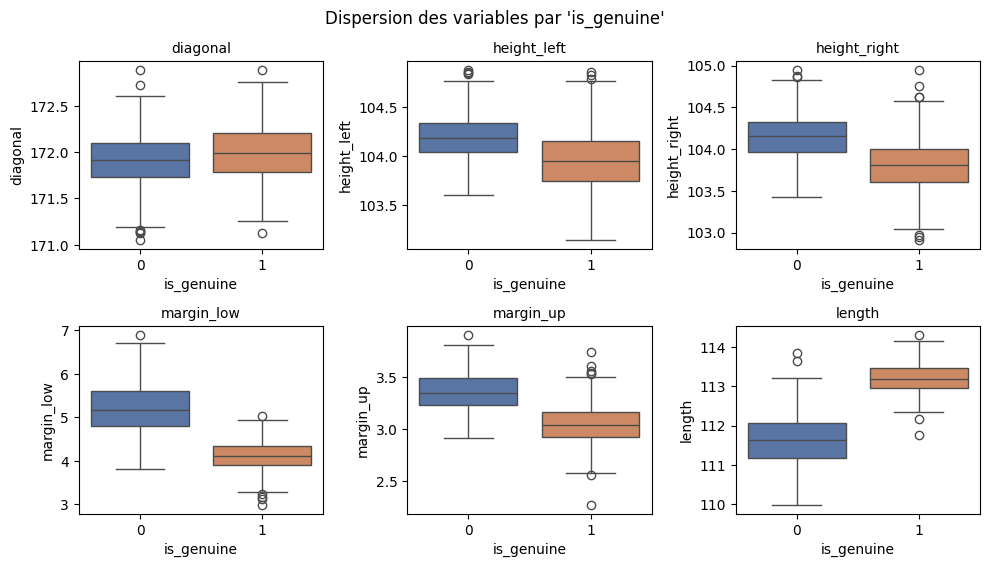

In [7]:
# Création de la figure avec une grille (ici 3 lignes x 3 colonnes pour 5 plots)
fig, axs = plt.subplots(3, 3, figsize=(10, 8))
axs = axs.flatten()

# Itérer sur chaque variable de list_variables et tracer le boxplot séparé par 'is_genuine'
for i, column in enumerate(list_variables):
    # Ici, on met 'is_genuine' en x pour séparer les groupes, et la variable étudiée en y.
    sns.boxplot(x='is_genuine', y=column, data=train, ax=axs[i], palette='deep')
    axs[i].set_title(column, size=10)
    axs[i].set_xlabel("is_genuine")
    axs[i].set_ylabel(column)

# Masquer les subplots non utilisés
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

fig.suptitle("Dispersion des variables par 'is_genuine'")
plt.tight_layout()
plt.show()


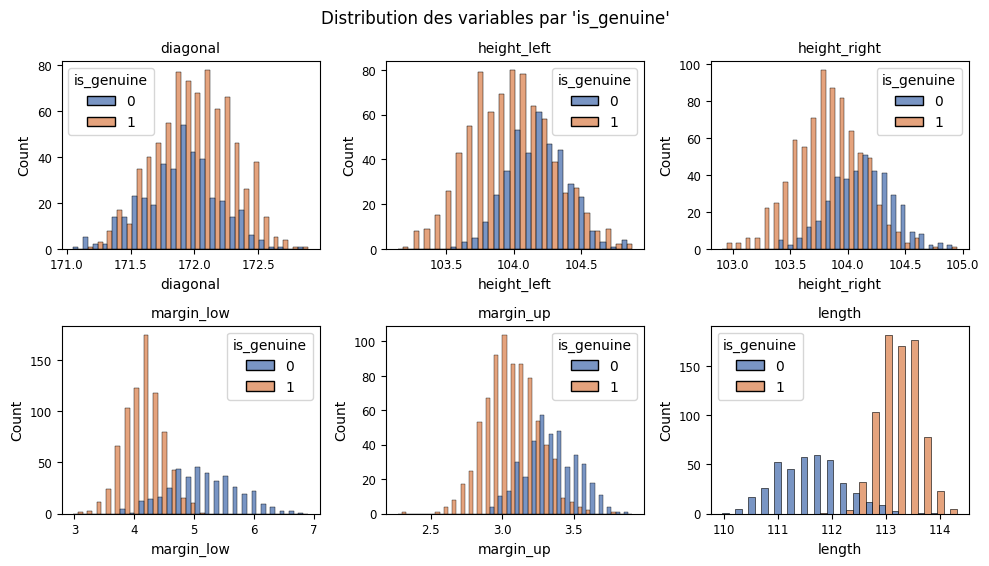

In [9]:
# Création de la figure avec une grille de subplots (3 lignes x 3 colonnes pour 5 plots)
fig, axs = plt.subplots(3, 3, figsize=(10, 8))
axs = axs.ravel()

# Itérer sur chaque variable de list_variables et tracer son histogramme avec 'is_genuine'
for i, column in enumerate(list_variables):
    sns.histplot(data=train, x=column, hue="is_genuine", bins="auto", 
                 ax=axs[i], palette="deep", multiple="dodge")
    axs[i].set_title(column, size=10)
    axs[i].tick_params(axis='both', which='both', labelsize=8.5)

# Masquer les subplots inutilisés
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

fig.suptitle("Distribution des variables par 'is_genuine'")
plt.tight_layout()
plt.show()


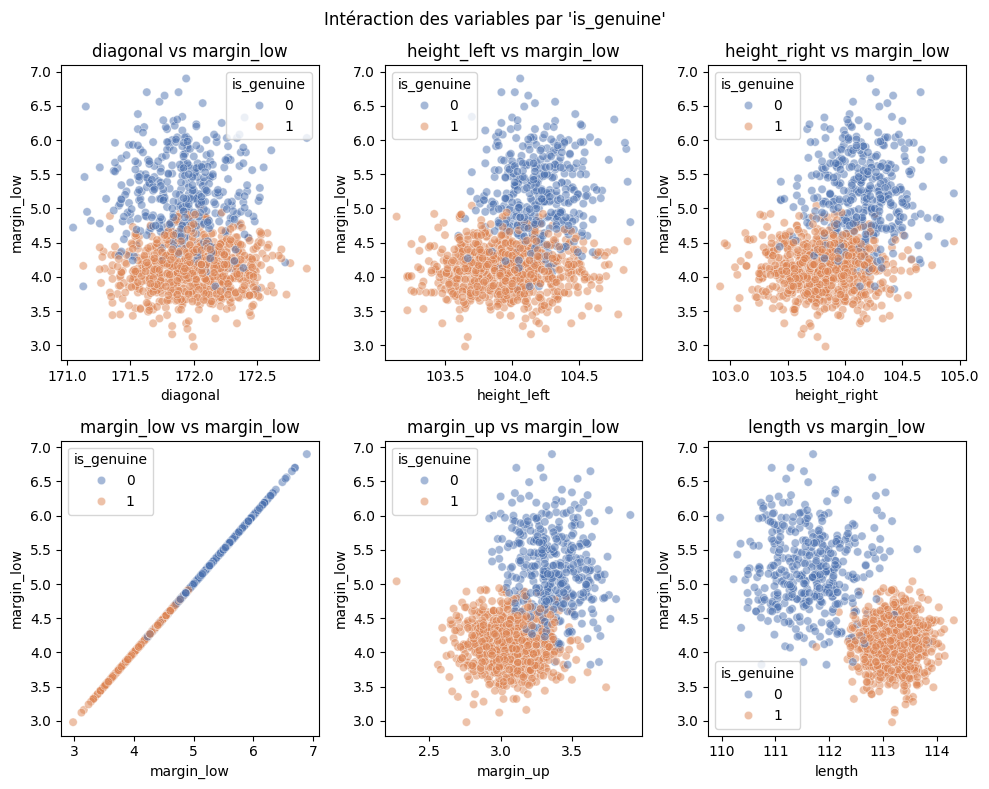

In [10]:
# Création des subplots : une grille avec 2 lignes et 3 colonnes pour 5 plots
fig, axs = plt.subplots(2, 3, figsize=(10, 8))
axs = axs.flatten()

# Itérer sur chaque variable de list_variables et tracer son scatterplot avec margin_low
for i, col in enumerate(list_variables):
    sns.scatterplot(x=col, y="margin_low", hue="is_genuine", data=train, 
                    ax=axs[i], alpha=0.5, palette="deep")
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("margin_low")
    axs[i].set_title(f"{col} vs margin_low")

# Masquer les subplots inutilisés
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

fig.suptitle("Intéraction des variables par 'is_genuine'")
plt.tight_layout()
plt.show()


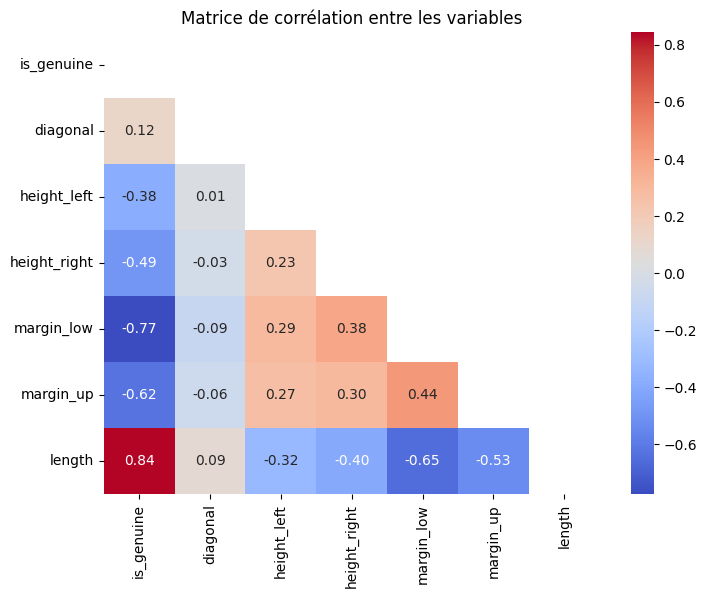

In [11]:
# Calculer la matrice de corrélation (par défaut, corrélation de Pearson)
corr_matrix_train = train.corr()

# Création d'un masque pour n'afficher que la demi-heatmap
mask = np.triu(np.ones_like(corr_matrix_train, dtype=bool))

# Afficher la matrice de corrélation avec une heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_train, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation entre les variables")
plt.show()

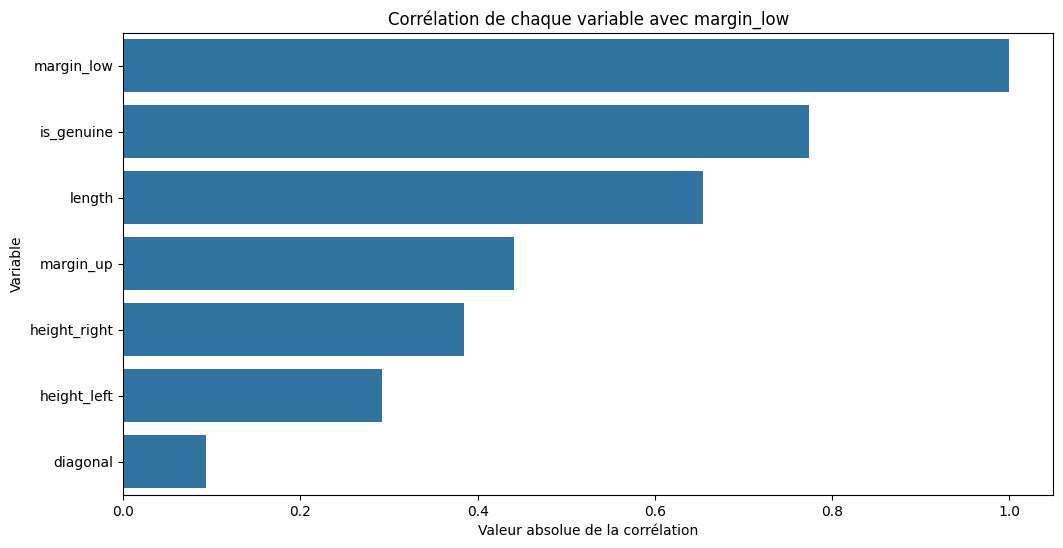

In [12]:
# Calcul de la corrélation entre chaque variable et la variable cible (en valeur absolue)
correlations = abs(train.corr()["margin_low"]).sort_values(ascending=False)

# Représentation graphique des corrélations
plt.figure(figsize=(12, 6))
sns.barplot(x=correlations.values, y=correlations.index)
plt.xlabel("Valeur absolue de la corrélation")
plt.ylabel("Variable")
plt.title("Corrélation de chaque variable avec margin_low")
plt.show()

`margin_low` est plutôt bien corrélée avec les autres variables à l'exception de `diagonal`. Elle est particulièrement corrélée à `length`.

## Modélisation sur la base de 'Train'

Pour ce cas de modélisation, nous utiliserons `statsmodels` qui nous permet d'avoir la significativité des coefficients et du modèle en général.  
Il est important d'ajouter la constante d'interception `sm.add_constant` à nos données d'entraînement.

In [13]:
# Séparation des variables prédictives et de la variable cible
X_train = train.drop(["margin_low", "is_genuine"], axis=1)
y_train = train["margin_low"]

X_test = test.drop(["margin_low", "is_genuine"], axis=1)
y_test = test["margin_low"]

# Fit du modèle linéaire
lr_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()

# Obtention du tableau de résultats
results_table = lr_model.summary2().tables[1]
results_table

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,20.396010,11.265864,1.810426,7.048756e-02,-1.707662,42.499681
diagonal,-0.087151,0.048232,-1.806921,7.103266e-02,-0.181782,0.007480
height_left,0.154745,0.051131,3.026451,2.528799e-03,0.054426,0.255064
height_right,0.259947,0.048384,5.372546,9.370058e-08,0.165017,0.354877
margin_up,0.290974,0.073292,3.970093,7.624626e-05,0.147176,0.434773
length,-0.398987,0.020702,-19.272639,4.719428e-72,-0.439605,-0.358369


Nous avons les différentes variables et leur coefficient. Lorsque la p-valeur de chaque coefficient est inférieure à 0.05, on accepte que le coefficient est significatif pour expliquer le phénomène.  
Dans notre cas et nous l'avions décelé dans nos analyses précédentes de corrélation, le coefficient de la variable `diagonal` n'est pas significatif.

**Il sera toutefois nécessaire de vérifier les hypothèses pour confirmer notre affirmation**.

Maintenant, nous allons voir la significativité globale de notre modèle.

In [14]:
lr_model.summary2().tables[0]

,0,1,2,3
0,Model:,OLS,Adj. R-squared:,0.458
1,Dependent Variable:,margin_low,AIC:,1663.1602
2,Date:,2025-04-08 08:03,BIC:,1693.5487
3,No. Observations:,1170,Log-Likelihood:,-825.58
4,Df Model:,5,F-statistic:,198.7
5,Df Residuals:,1164,Prob (F-statistic):,3.54e-153
6,R-squared:,0.460,Scale:,0.24135


En ayant ajouté la constante à notre modèle, nous pouvons interpréter le R2 (coefficient de détermination) à 0.46 comme pouvoir explicatif de notre modèle.  
Cela signifie que notre modèle explique à 46% la variabilité de la taille de `margin_low`, c'est qui est moyen en termes de résultat.

Ces résultats nous indiquent également le résultat du test de Fischer (significativité globale du modèle) et sa p-valeur qui est inférieure à 0.05, donc le modèle est significatif.  

**Il sera toutefois nécessaire de vérifier les hypothèses pour confirmer notre affirmation**.

Selon notre remarque précédente, nous allons retester notre modèle sans la variable `diagonal`.

In [15]:
# Séparation des variables prédictives et de la variable cible
X_train = train.drop(["margin_low", "diagonal", "is_genuine"], axis=1)
y_train = train["margin_low"]

X_test = test.drop(["margin_low", "diagonal", "is_genuine"], axis=1)
y_test = test["margin_low"]

# Ajouter une constante (intercept) aux variables explicatives pour statsmodels
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Ajuster le modèle de régression linéaire avec statsmodels
lr_model = sm.OLS(y_train, X_train_const).fit()

# Obtention du tableau de résultats
results_table = lr_model.summary2().tables[1]
results_table

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,6.077539,8.015664,0.758208,4.484799e-01,-9.649211,21.804290
height_left,0.150727,0.051132,2.947797,3.264247e-03,0.050406,0.251048
height_right,0.260242,0.048431,5.373456,9.322519e-08,0.165220,0.355264
margin_up,0.293534,0.073349,4.001879,6.680902e-05,0.149623,0.437445
length,-0.401552,0.020674,-19.423429,5.067319e-73,-0.442113,-0.360990


In [16]:
lr_model.summary2().tables[0]

,0,1,2,3
0,Model:,OLS,Adj. R-squared:,0.457
1,Dependent Variable:,margin_low,AIC:,1664.4374
2,Date:,2025-04-08 08:03,BIC:,1689.7612
3,No. Observations:,1170,Log-Likelihood:,-827.22
4,Df Model:,4,F-statistic:,247.1
5,Df Residuals:,1165,Prob (F-statistic):,1.07e-153
6,R-squared:,0.459,Scale:,0.24182


In [17]:
# Obtention des prédictions et des métriques d'évaluation
y_train_pred = lr_model.predict(sm.add_constant(X_train))
y_test_pred = lr_model.predict(sm.add_constant(X_test))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

In [18]:
# Construction du tableau de résultats

df_metrics = pd.DataFrame({
    'Métrique': ['R2', 'MSE', 'RMSE', 'MAE'],
    'Train (classique)': [r2_train, mse_train, rmse_train, mae_train],
    'Test (classique)': [r2_test, mse_test, rmse_test, mae_test]
})

print(df_metrics)

  Métrique  Train (classique)  Test (classique)
0       R2           0.458967          0.539260
1      MSE           0.240790          0.194204
2     RMSE           0.490704          0.440686
3      MAE           0.380884          0.336693


Notre R2 ne s'améliore pas, notre modèle est toujours moyen.  
A l'inverse, le carré moyen des erreurs (MSE) est plutôt proche de 0 ce qui est une bonne chose car c'est l'une des valeurs que l'on cherche à minimiser dans le cadre d'une régression.

Nous projetons les valeurs prédites en fonction des valeurs observées.

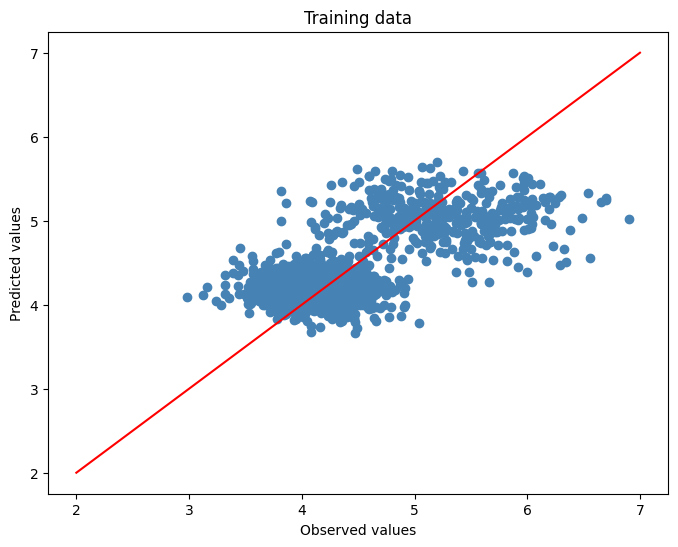

In [19]:
# Tracer les valeurs observées en fonction des valeurs prédites sur les données d'entraînement
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, color='steelblue')
plt.xlabel('Observed values')
plt.ylabel('Predicted values')
plt.title('Training data')
plt.plot(np.arange(2, 8, 1), np.arange(2, 8, 1), color='red')
plt.show()

Nous remarquons que nous avons des erreurs de prédiction. Les points des valeurs prédites s'éloignent de la droite (prédictions parfaites).

### Vérification des hypothèses du modèle

**1ère hypothèse : Linéarité du modèle**  

La relation entre les variables explicatives et la variable cible doit être linéaire. Pour vérifier cela, nous effectuons le test de Rainbow avec les hypothèses suivantes :  

* H<sub>0</sub> : Le modèle est correctement spécifié (linéarité)  si p-value > 0.05  
* H<sub>1</sub> : Le modèle pourrait être mal spécifié (non-linéaire) si p-value < 0.05

In [20]:
# Test de Rainbow
X_train_const = sm.add_constant(X_train)
rainbow_stat, rainbow_p_value = linear_rainbow(OLS(y_train, X_train_const).fit())
print("\nTest de Rainbow pour la linéarité :")
print("H0 : Le modèle est correctement spécifié (linéarité)")
print(f"Statistique : {rainbow_stat:.4f}, p-value : {rainbow_p_value:.4f}")
if rainbow_p_value < 0.05:
    print("Conclusion : Rejet de H0, le modèle pourrait être mal spécifié (non-linéaire).\n")
else:
    print("Conclusion : H0 non rejetée, le modèle est probablement linéaire.\n")


Test de Rainbow pour la linéarité :
H0 : Le modèle est correctement spécifié (linéarité)
Statistique : 1.1596, p-value : 0.0372
Conclusion : Rejet de H0, le modèle pourrait être mal spécifié (non-linéaire).



**2ème hypothèse : Homoscédasticité**  

L'homoscédasticité signifie que la variance des résidus est constante. Nous commençons par afficher les résidus sous forme de graphique.

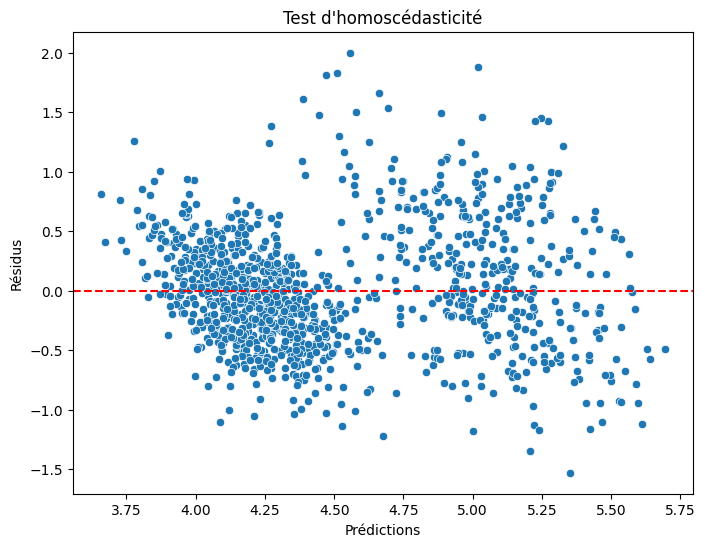

In [21]:
# Test d'homoscédasticité
y_train_pred = lr_model.predict(sm.add_constant(X_train))
residuals = y_train - y_train_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Test d\'homoscédasticité')
plt.xlabel('Prédictions')
plt.ylabel('Résidus')
plt.show()

Nous remarquons que les résidus sont dispersés de manière relativement uniforme autour de 0.  
Nous pourrions considèrer que l'homoscédasticité est satisfaite. Néanmoins, nous allons réaliser le test statistique de Breush-Pagan dont les hypothèses sont les suivantes :  

* H<sub>0</sub> : Les résidus sont homoscédastiques si p-value > 5 % ;
* H<sub>1</sub> : Rejet de H<sub>0</sub>, les résidus ne sont pas homoscédastiques si p-value < 5 %.

In [22]:
# Test de Breusch-Pagan
bp_test = sm.stats.diagnostic.het_breuschpagan(lr_model.resid, lr_model.model.exog)
print("Test de Breusch-Pagan pour l'homoscédasticité : statistique = %f, p-value = %f" % (bp_test[0], bp_test[1]))
print("H0 : Les résidus sont homoscédastiques (variance constante)")
if bp_test[1] < 0.05:
        print("Conclusion : Rejet de H0, les résidus ne sont pas homoscédastiques.\n")
else:
        print("Conclusion : H0 non rejetée, les résidus sont homoscédastiques.\n")

Test de Breusch-Pagan pour l'homoscédasticité : statistique = 68.052549, p-value = 0.000000
H0 : Les résidus sont homoscédastiques (variance constante)
Conclusion : Rejet de H0, les résidus ne sont pas homoscédastiques.



**3ème hypothèse : Multicolinéarité**  

Nous devons vérifier que dans notre modèle, les variables ne soient pas des combinaisons linéaires des autres variables ou que les variables aient de forte relation entre elles.  
Nous avions remarqué que certaines variables étaient fortement corrélées à d'autres.  

Afin de déterminer si cette hypothèse est validée, nous allons calculer le « VIF » (facteur d'inflation de variance) pour chaque variable explicative :  

* si **VIF = 1** : **pas de corrélation** entre les variables explicatives ;
* si **1 < VIF ≤ 5** : il y a une **corrélation modérée** mais ne nécessite pas forcément une attention particulière ;
* si **VIF > 5** : il y a une **corrélation importante** qui peut nuire au résultat de la régression.

In [23]:
# Vérification de la colinéarité (VIF)
X_train_const = sm.add_constant(X_train)  # Ajout d'une constante pour le VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_const.values, i) for i in range(X_train_const.shape[1])]

print("\nFacteur d'Inflation de la Variance (VIF) :")
print(vif_data)


Facteur d'Inflation de la Variance (VIF) :
       Variable            VIF
0         const  310860.507067
1   height_left       1.142644
2  height_right       1.217585
3     margin_up       1.434674
4        length       1.582255


Toutes les valeurs sont proches de 1, il n'y a donc pas de problème de multicolinéarité.

**4ème hypothèse : Normalité des résidus**  

Les valeurs des résidus doivent suivre une loi normale. On trace la distribution des résidus.

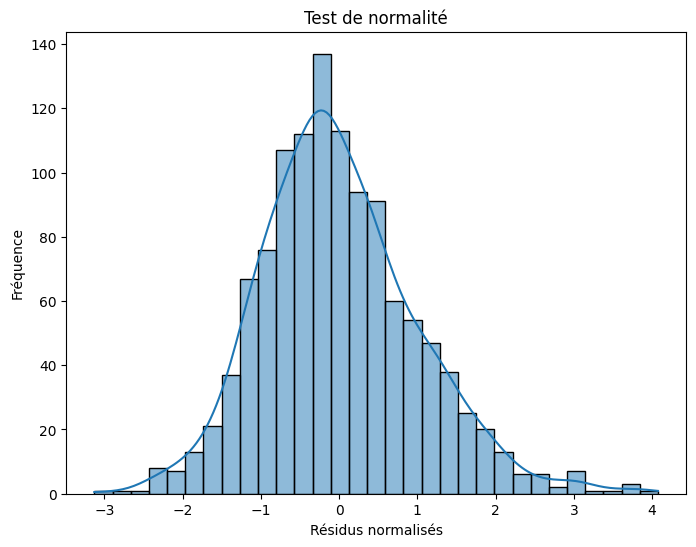

In [24]:
# Test de normalité
resid_norm = lr_model.get_influence().resid_studentized_internal
plt.figure(figsize=(8, 6))
sns.histplot(resid_norm, kde=True)
plt.title('Test de normalité')
plt.xlabel('Résidus normalisés')
plt.ylabel('Fréquence')
plt.show()

La distribution des résidus ne semble pas symétrique.  
Nous affichons un QQ-plot pour confirmation.

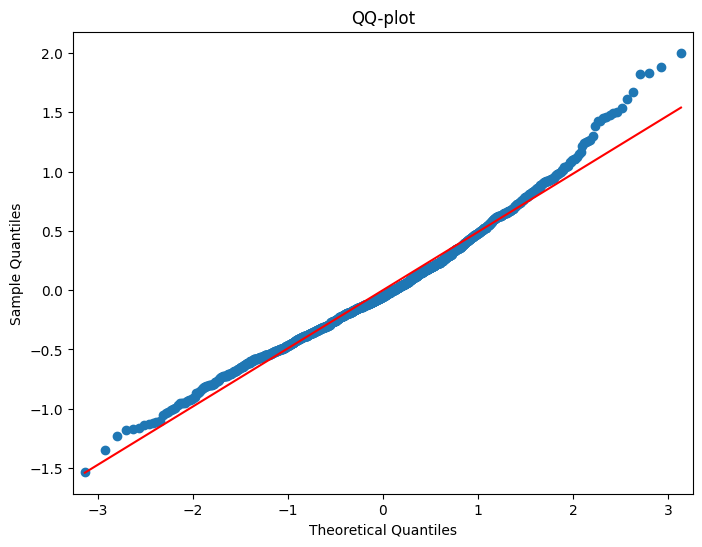

In [25]:
# QQ-plot
fig, ax = plt.subplots(figsize=(8, 6))
sm.qqplot(residuals, line='s', ax=ax)
ax.set_title('QQ-plot')
plt.show()

Pour vérifier cela, nous allons réaliser un test de Shapiro-Wilk ayant les hypothèses suivantes :

* H<sub>0</sub> : Les résidus suivent une distribution normale si p-value > 5 % ;
* H<sub>1</sub> : Rejet de H0, les résidus ne sont pas normalement distribués si p-value < 5 %

et le test de Kolmogorov-Smirnov avec les hypothèses suivantes :  

* H<sub>0</sub> : Les résidus suivent une distribution normale si p-value > 5 % ;
* H<sub>1</sub> : Rejet de H0, les résidus ne suivent pas une distribution normale si p-value < 5 %

In [26]:
# Test de Shapiro-Wilk
shapiro_test = stats.shapiro(residuals)

# Test de Kolmogorov-Smirnov
ks_test = stats.kstest(residuals, 'norm')

# Mettre les résultats dans un dataframe
df_normality = pd.DataFrame({
    'Test de normalité': ['Shapiro-Wilk', 'Kolmogorov-Smirnov'],
    'Statistique': [shapiro_test.statistic, ks_test.statistic],
    'p-value': [shapiro_test.pvalue, ks_test.pvalue]
})

# Afficher le tableau
print(df_normality)

if shapiro_test.pvalue < 0.05:
    print("Conclusion Shapiro-Wilk : Rejet de H0, les résidus ne sont pas normalement distribués.\n")
else:
    print("Conclusion Shapiro-Wilk : H0 non rejetée, les résidus suivent une distribution normale.\n")
        
if ks_test.pvalue < 0.05:
    print("Conclusion Kolmogorov-Smirnov : Rejet de H0, les résidus ne suivent pas une distribution normale.\n")
else:
    print("Conclusion Kolmogorov-Smirnov : H0 non rejetée, les résidus suivent une distribution normale.\n")

    Test de normalité  Statistique       p-value
0        Shapiro-Wilk     0.983510  2.958290e-10
1  Kolmogorov-Smirnov     0.194123  4.249702e-39
Conclusion Shapiro-Wilk : Rejet de H0, les résidus ne sont pas normalement distribués.

Conclusion Kolmogorov-Smirnov : Rejet de H0, les résidus ne suivent pas une distribution normale.



Nous allons tester maintenant la régression linéaire avec des données normalisées.

## Régression linéaire (données normalisées)

In [27]:
# Création et ajustement du scaler sur l'ensemble d'entraînement
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transformation de l'ensemble de test avec le scaler ajusté sur l'entraînement
X_test_scaled = scaler.transform(X_test)

In [28]:
# Ajouter une constante (intercept) aux variables explicatives pour statsmodels
X_train_const = sm.add_constant(X_train_scaled)
X_test_const = sm.add_constant(X_test_scaled)

# Ajuster le modèle de régression linéaire avec statsmodels
lr_model_scaled = sm.OLS(y_train, X_train_const).fit()

# Obtention du tableau de résultats
results_table = lr_model_scaled.summary2().tables[1]
results_table

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,4.484786,0.014377,311.950043,0.000000e+00,4.456579,4.512993
x1,0.045301,0.015368,2.947797,3.264247e-03,0.015150,0.075453
x2,0.085243,0.015864,5.373456,9.322519e-08,0.054119,0.116368
x3,0.068912,0.017220,4.001879,6.680902e-05,0.035127,0.102698
x4,-0.351254,0.018084,-19.423429,5.067319e-73,-0.386735,-0.315773


In [29]:
lr_model_scaled.summary2().tables[0]

,0,1,2,3
0,Model:,OLS,Adj. R-squared:,0.457
1,Dependent Variable:,margin_low,AIC:,1664.4374
2,Date:,2025-04-08 08:03,BIC:,1689.7612
3,No. Observations:,1170,Log-Likelihood:,-827.22
4,Df Model:,4,F-statistic:,247.1
5,Df Residuals:,1165,Prob (F-statistic):,1.07e-153
6,R-squared:,0.459,Scale:,0.24182


In [30]:
# Obtention des prédictions et des métriques d'évaluation
y_train_pred_scaled = lr_model_scaled.predict(X_train_const)
y_test_pred_scaled = lr_model_scaled.predict(X_test_const)
r2_train_scaled = r2_score(y_train, y_train_pred_scaled)
r2_test_scaled = r2_score(y_test, y_test_pred_scaled)
mse_train_scaled = mean_squared_error(y_train, y_train_pred_scaled)
mse_test_scaled = mean_squared_error(y_test, y_test_pred_scaled)
rmse_train_scaled = np.sqrt(mse_train_scaled)
rmse_test_scaled = np.sqrt(mse_test_scaled)
mae_train_scaled = mean_absolute_error(y_train, y_train_pred_scaled)
mae_test_scaled = mean_absolute_error(y_test, y_test_pred_scaled)

In [31]:
# --- Mise à jour du tableau de comparaison ---
# On ajoute deux nouvelles colonnes pour le modèle scaled
df_metrics["Train (classique_scaled)"] = [r2_train_scaled, mse_train_scaled, rmse_train_scaled, mae_train_scaled]
df_metrics["Test (classique_scaled)"] = [r2_test_scaled, mse_test_scaled, rmse_test_scaled, mae_test_scaled]

# Affichage du tableau de comparaison final
print("\nComparaison des métriques pour les différents modèles :")
print(df_metrics)


Comparaison des métriques pour les différents modèles :
  Métrique  Train (classique)  Test (classique)  Train (classique_scaled)  \
0       R2           0.458967          0.539260                  0.458967   
1      MSE           0.240790          0.194204                  0.240790   
2     RMSE           0.490704          0.440686                  0.490704   
3      MAE           0.380884          0.336693                  0.380884   

   Test (classique_scaled)  
0                 0.539260  
1                 0.194204  
2                 0.440686  
3                 0.336693  


Les données normalisées n'apportent aucun changement aux résultats.  
Nos données d'entraînement peuvent contenir des valeurs aberrantes ou influentes.  
Nous allons tester à nouveau notre régression linéaire sans ces valeurs.

## Régression linéaire (données nettoyées des outliers)

In [32]:
# Séparation des variables prédictives et de la variable cible
X_train = train.drop(["margin_low", "diagonal", "is_genuine"], axis=1)
y_train = train["margin_low"]

X_test = test.drop(["margin_low", "diagonal", "is_genuine"], axis=1)
y_test = test["margin_low"]

# Ajouter une constante (intercept) aux variables explicatives pour statsmodels
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)


L'objectif est de d'identifier les outliers potentiels.  
Pour faire cela, nous mesurons :  

**Résidus studentisés externes :**  
Ils mesurent l’écart standardisé entre la valeur observée et la valeur prédite, recalculé en excluant l’observation, ce qui permet d’identifier les outliers potentiels.  
**Distance de Cook :**  
Elle évalue l’influence globale d’une observation sur tous les coefficients du modèle, aidant à repérer les points qui, s’ils sont supprimés, modifieraient significativement l’ajustement.  
**DFFITS :**  
Cette mesure quantifie l’impact d’une observation sur sa propre prédiction, indiquant à quel point une observation influe sur le résultat du modèle.  
**Levier (hat matrix diagonal) :**  
Il reflète la position d’une observation dans l’espace des variables explicatives, identifiant les points susceptibles d’avoir une forte influence sur l’ajustement du modèle.

In [33]:
# Extraction des diagnostics d'influence
influence = lr_model.get_influence()

# Résidus studentisés externes
stud_res = influence.resid_studentized_external

# Distance de Cook
cooks_d, _ = influence.cooks_distance

# DFFITS
dffits, _ = influence.dffits

# Diagonale de la matrice hat (levier)
leverage = influence.hat_matrix_diag


Nous calculons les différents seuils.

In [34]:
n = X_train_const.shape[0]  # nombre d'observations d'entraînement
p = X_train_const.shape[1]  # nombre de paramètres (incluant l'intercept)

# Seuils
threshold_stud = 2.0
threshold_cook = 4 / n
threshold_dffits = 2 * np.sqrt(p / n)
threshold_leverage = 2 * (p) / n  # ou 3*(p)/n selon la rigueur souhaitée

print(f"Seuil résidus studentisés : {threshold_stud}")
print(f"Seuil Cook : {threshold_cook}")
print(f"Seuil DFFITS : {threshold_dffits}")
print(f"Seuil Levier : {threshold_leverage}")


Seuil résidus studentisés : 2.0
Seuil Cook : 0.003418803418803419
Seuil DFFITS : 0.1307440900921227
Seuil Levier : 0.008547008547008548


Nous pouvons ensuite extraire les outliers possibles si au moins 1 des 4 seuils est dépassé.

In [35]:
# Création d'un DataFrame récapitulatif des diagnostics
diagnostics = pd.DataFrame({
    'stud_res': stud_res,
    'cooks_distance': cooks_d,
    'dffits': dffits,
    'leverage': leverage
}, index=X_train_const.index)

# Marquage des observations qui dépassent les seuils
diagnostics['outlier'] = (diagnostics['stud_res'].abs() > threshold_stud) | \
                         (diagnostics['cooks_distance'] > threshold_cook) | \
                         (diagnostics['dffits'].abs() > threshold_dffits) | \
                         (diagnostics['leverage'] > threshold_leverage)

# Affichage des observations marquées comme outliers/influentes
print("Observations atypiques et/ou influentes :")
print(diagnostics[diagnostics['outlier']])


Observations atypiques et/ou influentes :
      stud_res  cooks_distance    dffits  leverage  outlier
1229  2.059705        0.002875  0.120072  0.003387     True
1484  0.306019        0.000205  0.031996  0.010814     True
1284  2.006132        0.003177  0.126204  0.003942     True
965  -2.507201        0.008939 -0.211886  0.007091     True
292   2.065134        0.007518  0.194153  0.008761     True
...        ...             ...       ...       ...      ...
34    0.908412        0.001690  0.091921  0.010135     True
577   1.922804        0.004388  0.148294  0.005913     True
1331 -0.246142        0.000145 -0.026895  0.011798     True
1367  2.656370        0.004295  0.146931  0.003050     True
1270  0.243538        0.000134  0.025905  0.011188     True

[126 rows x 5 columns]


Nous avons ainsi décelé 126 outliers potentiels dans nos données d'entraînement.

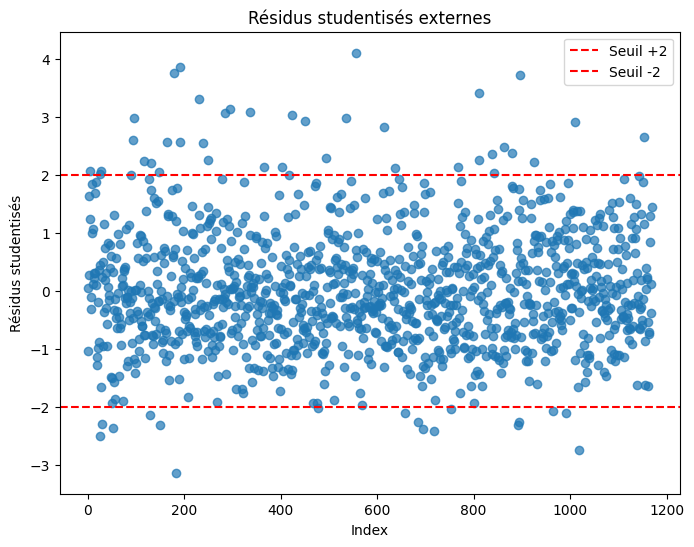

In [36]:
# Graphique des résidus studentisés
plt.figure(figsize=(8, 6))
# Utiliser np.arange(len(stud_res)) comme axe x
plt.scatter(np.arange(len(stud_res)), stud_res, alpha=0.7)
plt.axhline(threshold_stud, color='red', linestyle='--', label='Seuil +2')
plt.axhline(-threshold_stud, color='red', linestyle='--', label='Seuil -2')
plt.title("Résidus studentisés externes")
plt.xlabel("Index")
plt.ylabel("Résidus studentisés")
plt.legend()
plt.show()


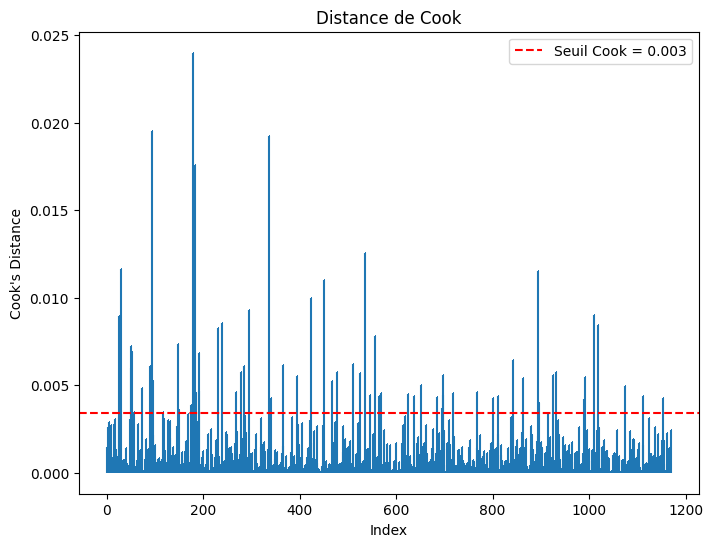

In [37]:
# Graphique de la distance de Cook
plt.figure(figsize=(8, 6))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", basefmt=" ")
plt.axhline(threshold_cook, color='red', linestyle='--', label=f'Seuil Cook = {threshold_cook:.3f}')
plt.title("Distance de Cook")
plt.xlabel("Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.show()


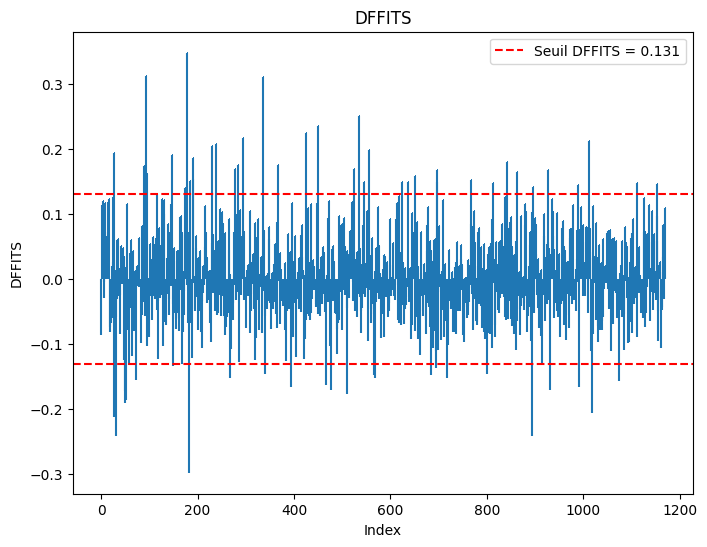

In [38]:
# Graphique de DFFITS
plt.figure(figsize=(8, 6))
plt.stem(np.arange(len(dffits)), dffits, markerfmt=",", basefmt=" ")
plt.axhline(threshold_dffits, color='red', linestyle='--', label=f'Seuil DFFITS = {threshold_dffits:.3f}')
plt.axhline(-threshold_dffits, color='red', linestyle='--')
plt.title("DFFITS")
plt.xlabel("Index")
plt.ylabel("DFFITS")
plt.legend()
plt.show()


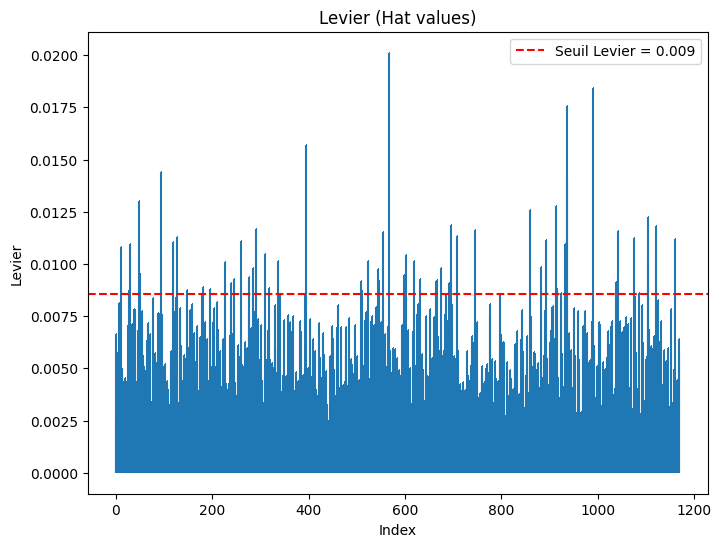

In [39]:
# Graphique des leviers
plt.figure(figsize=(8, 6))
plt.stem(np.arange(len(leverage)), leverage, markerfmt=",", basefmt=" ")
plt.axhline(threshold_leverage, color='red', linestyle='--', label=f'Seuil Levier = {threshold_leverage:.3f}')
plt.title("Levier (Hat values)")
plt.xlabel("Index")
plt.ylabel("Levier")
plt.legend()
plt.show()


Nous supprimons ces 126 outliers de nos données d'entraînement.

In [40]:
indices_to_keep = diagnostics[~diagnostics['outlier']].index
X_train_clean = X_train_const.loc[indices_to_keep]
y_train_clean = y_train.loc[indices_to_keep]


Nous testons notre régression linéaire sans les outliers.

In [41]:
# Ajouter une constante (intercept) aux variables explicatives pour statsmodels
X_train_const = sm.add_constant(X_train_clean)
X_test_const = sm.add_constant(X_test)

lr_model_clean = sm.OLS(y_train_clean, X_train_const).fit()
print(lr_model_clean.summary())


                            OLS Regression Results                            
Dep. Variable:             margin_low   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     293.8
Date:                Tue, 08 Apr 2025   Prob (F-statistic):          5.36e-169
Time:                        08:03:48   Log-Likelihood:                -526.08
No. Observations:                1044   AIC:                             1062.
Df Residuals:                    1039   BIC:                             1087.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           11.0954      7.554      1.469   

In [42]:
# Obtention des prédictions pour l'ensemble d'entraînement et l'ensemble de test
y_train_pred_clean = lr_model_clean.predict(X_train_const)
y_test_pred_clean  = lr_model_clean.predict(X_test_const)

# Calcul des métriques pour l'ensemble d'entraînement
r2_train_clean = r2_score(y_train_clean, y_train_pred_clean)
r2_test_clean = r2_score(y_test, y_test_pred_clean)
mse_train_clean = mean_squared_error(y_train_clean, y_train_pred_clean)
mse_test_clean = mean_squared_error(y_test, y_test_pred_clean)
rmse_train_clean = np.sqrt(mse_train_clean)
rmse_test_clean = np.sqrt(mse_test_clean)
mae_train_clean = mean_absolute_error(y_train_clean, y_train_pred_clean)
mae_test_clean = mean_absolute_error(y_test, y_test_pred_clean)


In [43]:
# --- Mise à jour du tableau de comparaison ---
# On ajoute deux nouvelles colonnes pour le modèle clean
df_metrics["Train (clean)"] = [r2_train_clean, mse_train_clean, rmse_train_clean, mae_train_clean]
df_metrics["Test (clean)"] = [r2_test_clean, mse_test_clean, rmse_test_clean, mae_test_clean]

# Affichage du tableau de comparaison final
print("\nComparaison des métriques pour les différents modèles :")
print(df_metrics)


Comparaison des métriques pour les différents modèles :
  Métrique  Train (classique)  Test (classique)  Train (classique_scaled)  \
0       R2           0.458967          0.539260                  0.458967   
1      MSE           0.240790          0.194204                  0.240790   
2     RMSE           0.490704          0.440686                  0.490704   
3      MAE           0.380884          0.336693                  0.380884   

   Test (classique_scaled)  Train (clean)  Test (clean)  
0                 0.539260       0.530765      0.535675  
1                 0.194204       0.160404      0.195715  
2                 0.440686       0.400504      0.442397  
3                 0.336693       0.326336      0.336117  


# RIDGE

In [44]:
# 1. Définir la grille des hyperparamètres à tester pour alpha
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# 2. Instanciation du modèle Ridge avec une graine pour la reproductibilité
ridge = Ridge(random_state=42)

# 3. Configuration de GridSearchCV avec validation croisée (5 plis) et en utilisant le score R² comme métrique
grid_search_ridge = GridSearchCV(estimator=ridge,
                                 param_grid=param_grid_ridge,
                                 cv=5,
                                 scoring='r2',
                                 n_jobs=-1)

# 4. Entraînement avec GridSearchCV sur l'ensemble d'entraînement
grid_search_ridge.fit(X_train, y_train)

# 5. Affichage des meilleurs paramètres et du meilleur score de validation
print("Meilleurs paramètres trouvés :", grid_search_ridge.best_params_)
print("Meilleur score de validation (R²) :", grid_search_ridge.best_score_)

# 6. Récupération du meilleur modèle optimisé
best_ridge = grid_search_ridge.best_estimator_

# 7. Prédictions sur l'ensemble d'entraînement et de test
y_train_pred_ridge = best_ridge.predict(X_train)
y_test_pred_ridge = best_ridge.predict(X_test)

# 8. Calcul des métriques pour le modèle Ridge
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)
mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
rmse_train_ridge = np.sqrt(mse_train_ridge)
rmse_test_ridge = np.sqrt(mse_test_ridge)
mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
mae_test_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

# 9. Mise à jour du DataFrame de résultats (df_metrics)
# On ajoute deux nouvelles colonnes pour le modèle Ridge
df_metrics["Train (Ridge)"] = [r2_train_ridge, mse_train_ridge, rmse_train_ridge, mae_train_ridge]
df_metrics["Test (Ridge)"] = [r2_test_ridge, mse_test_ridge, rmse_test_ridge, mae_test_ridge]

print("\nComparaison des métriques pour les différents modèles :")
print(df_metrics)


Meilleurs paramètres trouvés : {'alpha': 10}
Meilleur score de validation (R²) : 0.4531440415609273

Comparaison des métriques pour les différents modèles :
  Métrique  Train (classique)  Test (classique)  Train (classique_scaled)  \
0       R2           0.458967          0.539260                  0.458967   
1      MSE           0.240790          0.194204                  0.240790   
2     RMSE           0.490704          0.440686                  0.490704   
3      MAE           0.380884          0.336693                  0.380884   

   Test (classique_scaled)  Train (clean)  Test (clean)  Train (Ridge)  \
0                 0.539260       0.530765      0.535675       0.458723   
1                 0.194204       0.160404      0.195715       0.240899   
2                 0.440686       0.400504      0.442397       0.490815   
3                 0.336693       0.326336      0.336117       0.380802   

   Test (Ridge)  
0      0.539343  
1      0.194169  
2      0.440647  
3      0.33616

# LASSO

In [45]:
# Définir la grille des hyperparamètres à tester pour alpha
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Instanciation du modèle Lasso avec une graine pour la reproductibilité
lasso = Lasso(random_state=42)

# Configuration de GridSearchCV avec validation croisée (5 plis) et en utilisant le score R² comme métrique
grid_search = GridSearchCV(estimator=lasso,
                           param_grid=param_grid,
                           cv=5,
                           scoring='r2',
                           n_jobs=-1)

# Entraînement avec GridSearchCV sur l'ensemble d'entraînement
grid_search.fit(X_train, y_train)

# Affichage des meilleurs paramètres et du meilleur score de validation
print("Meilleurs paramètres trouvés :", grid_search.best_params_)
print("Meilleur score de validation (R²) :", grid_search.best_score_)

# Récupération du meilleur modèle optimisé
best_lasso = grid_search.best_estimator_

# Prédictions sur l'ensemble d'entraînement et de test
y_train_pred_lasso = best_lasso.predict(X_train)
y_test_pred_lasso = best_lasso.predict(X_test)

# Calcul des métriques pour le modèle Lasso
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)
mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)
rmse_train_lasso = np.sqrt(mse_train_lasso)
rmse_test_lasso = np.sqrt(mse_test_lasso)
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
mae_test_lasso = mean_absolute_error(y_test, y_test_pred_lasso)

# --- Mise à jour du tableau de comparaison ---
# On ajoute deux nouvelles colonnes pour le modèle Lasso
df_metrics["Train (Lasso)"] = [r2_train_lasso, mse_train_lasso, rmse_train_lasso, mae_train_lasso]
df_metrics["Test (Lasso)"] = [r2_test_lasso, mse_test_lasso, rmse_test_lasso, mae_test_lasso]

# Affichage du tableau de comparaison final
print("\nComparaison des métriques pour les différents modèles :")
print(df_metrics)


Meilleurs paramètres trouvés : {'alpha': 0.001}
Meilleur score de validation (R²) : 0.4529642873557026

Comparaison des métriques pour les différents modèles :
  Métrique  Train (classique)  Test (classique)  Train (classique_scaled)  \
0       R2           0.458967          0.539260                  0.458967   
1      MSE           0.240790          0.194204                  0.240790   
2     RMSE           0.490704          0.440686                  0.490704   
3      MAE           0.380884          0.336693                  0.380884   

   Test (classique_scaled)  Train (clean)  Test (clean)  Train (Ridge)  \
0                 0.539260       0.530765      0.535675       0.458723   
1                 0.194204       0.160404      0.195715       0.240899   
2                 0.440686       0.400504      0.442397       0.490815   
3                 0.336693       0.326336      0.336117       0.380802   

   Test (Ridge)  Train (Lasso)  Test (Lasso)  
0      0.539343       0.458897      

# Régression linéaire (transformation log)

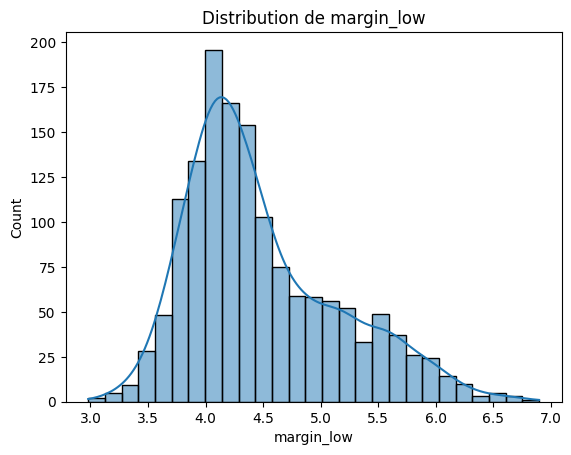

In [46]:
sns.histplot(df["margin_low"], kde=True)
plt.title("Distribution de margin_low")
plt.show()

In [47]:
# Si margin_low > 0 pour toutes les lignes, on peut appliquer log directement
# Sinon, on ajoute 1 pour éviter log(0)
df["margin_low_log"] = np.log(df["margin_low"])


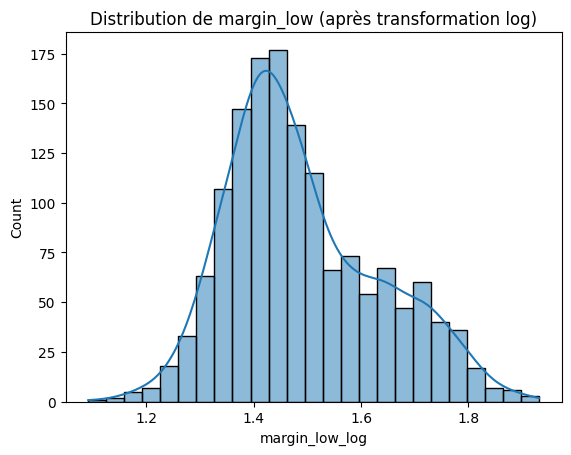

In [48]:
sns.histplot(df["margin_low_log"], kde=True)
plt.title("Distribution de margin_low (après transformation log)")
plt.show()


In [49]:
# Définir la variable cible transformée et les variables explicatives
target = "margin_low_log"
features = ["height_left", "height_right", "margin_up", "length"]

# Séparer les enregistrements complets (où target n'est pas manquant)
df_train = df.dropna(subset=[target])
df_missing = df[df[target].isnull()]

# Réaliser le train/test split sur les données complètes
train, test = train_test_split(df_train, test_size=0.2, random_state=42)

# Préparer X et y
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

# Ajouter une constante (intercept) aux variables explicatives pour statsmodels
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Ajuster le modèle de régression linéaire avec statsmodels
lr_model_log = sm.OLS(y_train, X_train_const).fit()

# Afficher le résumé du modèle
print(lr_model_log.summary())

# Obtenir les prédictions sur les ensembles d'entraînement et de test
y_train_pred = lr_model_log.predict(X_train_const)
y_test_pred = lr_model_log.predict(X_test_const)

# Afficher quelques métriques (vous pouvez utiliser d'autres fonctions pour un résumé complet)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_train_log = r2_score(y_train, y_train_pred)
r2_test_log = r2_score(y_test, y_test_pred)
mse_train_log = mean_squared_error(y_train, y_train_pred)
mse_test_log = mean_squared_error(y_test, y_test_pred)
rmse_train_log = np.sqrt(mse_train)
rmse_test_log = np.sqrt(mse_test)
mae_train_log = mean_absolute_error(y_train, y_train_pred)
mae_test_log = mean_absolute_error(y_test, y_test_pred)

# --- Mise à jour du tableau de comparaison ---
# On ajoute deux nouvelles colonnes pour le modèle log
df_metrics["Train (classique_log)"] = [r2_train_log, mse_train_log, rmse_train_log, mae_train_log]
df_metrics["Test (classique_log)"] = [r2_test_log, mse_test_log, rmse_test_log, mae_test_log]

# Affichage du tableau de comparaison final
print("\nComparaison des métriques pour les différents modèles :")
print(df_metrics)


                            OLS Regression Results                            
Dep. Variable:         margin_low_log   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     243.8
Date:                Tue, 08 Apr 2025   Prob (F-statistic):          3.72e-152
Time:                        08:04:14   Log-Likelihood:                 975.92
No. Observations:                1170   AIC:                            -1942.
Df Residuals:                    1165   BIC:                            -1917.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.8892      1.716      1.101   

In [50]:
df_metrics.head()

,Métrique,Train (classique),Test (classique),Train (classique_scaled),Test (classique_scaled),Train (clean),Test (clean),Train (Ridge),Test (Ridge),Train (Lasso),Test (Lasso),Train (classique_log),Test (classique_log)
0,R2,0.458967,0.539260,0.458967,0.539260,0.530765,0.535675,0.458723,0.539343,0.458897,0.539237,0.455658,0.528864
1,MSE,0.240790,0.194204,0.240790,0.194204,0.160404,0.195715,0.240899,0.194169,0.240822,0.194214,0.011041,0.009254
2,RMSE,0.490704,0.440686,0.490704,0.440686,0.400504,0.442397,0.490815,0.440647,0.490736,0.440697,0.490704,0.440686
3,MAE,0.380884,0.336693,0.380884,0.336693,0.326336,0.336117,0.380802,0.336160,0.380857,0.336323,0.082849,0.074505


## Résumé Complétion des valeurs manquantes

Nos différents tests de complétion des valeurs manquantes de la variable `margin_low` n'ont pas permis d'améliorer le score du coefficient de détermination (R2), que je qualifie de moyen.  
Par ailleurs, les hypothèses n'ont pas pu être vérifiées/validées.
Nos données manquantes ne représentent que 2,5 % des données.  
S'agissant de la sensibilité du projet, à savoir, la prédiction des billets, nous décidons donc du supprimer ces enregistrements et continuerons nos analyses pour la prédicition des billets  
sur la base de ces données nettoyées.

In [51]:
df = df.dropna().reset_index(drop=True)


In [52]:
df = df.drop('margin_low_log', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1463 entries, 0 to 1462
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1463 non-null   int64  
 1   diagonal      1463 non-null   float64
 2   height_left   1463 non-null   float64
 3   height_right  1463 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1463 non-null   float64
 6   length        1463 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 80.1 KB


# Prédiction des billets (vrais/faux)

Pour la prédiction des billets, nous allons tester différents modèles de classification (supervisés et non-supervisés) :  

* La régression logistique (supervisé)  
* K-Means (non-supervisé)  
* KNN (supervisé)  
* Decision Tree (supervisé)  
* Random-Forest (supervisé)  
 

Pour chaque modèle, nous essayerons d'augmenter leur robustesse.

Mais avant de réaliser les tests, nous effectuons une analyse exploratoire de nos données.

In [53]:
def my_first_analyse(data, graphique=False):
    """
    Effectue une analyse exploratoire des données et renvoie un résumé statistique.
    Args:
        df (pandas.DataFrame): DataFrame contenant les données à analyser.
    Returns:
        summary (pandas.DataFrame): DataFrame contenant un résumé statistique des données.
    """
    # Calcul du nombre d'observations et de variables
    nb_observations, nb_variables = data.shape
    
    # Exclure les colonnes non numériques
    data_numerique = data.select_dtypes(include=['number'])
    
    # Calcul des statistiques descriptives uniquement sur les colonnes numériques
    moyennes = data_numerique.mean()
    medianes = data_numerique.median()
    ecart_types = data_numerique.std()
    mini = data_numerique.min()
    maxi = data_numerique.max()
    nb_valeurs_manquantes = data_numerique.isnull().sum()
    data_type = data_numerique.dtypes
    
    # Calcul du nombre de valeurs uniques par colonne
    nb_valeurs_uniques = data.nunique()
    
    # Calcul des 5 premières valeurs les plus fréquentes par colonne
    top5_valeurs_frequentes = data.apply(lambda x: ';'.join(x.value_counts().index[:5].astype(str)))
    
    # Création du DataFrame de résumé statistique
    summary = pd.DataFrame({
        'observations': nb_observations,
        'variables': nb_variables,
        'type' : data_type,
        'moyennes': moyennes,
        'medianes': medianes,
        'ecart_types': ecart_types,
        'min': mini,
        'max': maxi,
        'nb_valeurs_manquantes': nb_valeurs_manquantes,
        '%_valeurs_manquantes' : round((nb_valeurs_manquantes/nb_observations)*100, 2),
        'nb_valeurs_uniques': nb_valeurs_uniques,
        'top5_valeurs_frequentes': top5_valeurs_frequentes
    })
    
    if graphique:
        # Affichage graphique
        plt.figure(figsize=(20, 20))
        sns.heatmap(data.isna(), cbar=None)
        plt.title("Représentation graphique des valeurs manquantes")
        plt.show()
    
    return summary


In [54]:
my_first_analyse(df)

,observations,variables,type,moyennes,medianes,ecart_types,min,max,nb_valeurs_manquantes,%_valeurs_manquantes,nb_valeurs_uniques,top5_valeurs_frequentes
is_genuine,1463,7,int64,0.663705,1.00,0.472603,0.00,1.00,0,0.0,2,1;0
diagonal,1463,7,float64,171.959193,171.96,0.305457,171.04,173.01,0,0.0,158,171.99;171.91;171.95;171.94;172.1
height_left,1463,7,float64,104.031333,104.04,0.299605,103.14,104.88,0,0.0,154,103.95;104.18;104.05;103.99;104.17
height_right,1463,7,float64,103.921476,103.92,0.324181,102.91,104.95,0,0.0,169,103.76;103.83;103.82;103.85;103.94
margin_low,1463,7,float64,4.485967,4.31,0.663813,2.98,6.90,0,0.0,285,4.18;4.1;4.08;4.17;4.12
margin_up,1463,7,float64,3.153083,3.14,0.231466,2.27,3.91,0,0.0,123,3.08;3.12;3.14;3.31;2.99
length,1463,7,float64,112.674757,112.96,0.873222,109.49,114.32,0,0.0,332,113.38;113.42;113.09;113.28;113.02


In [55]:
# Affiche le nombre de vrais/faux billets
df['is_genuine'].value_counts()

is_genuine
1    971
0    492
Name: count, dtype: int64

In [56]:
df.head(3)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,1,171.81,104.86,104.95,4.52,2.89,112.83
1,1,171.46,103.36,103.66,3.77,2.99,113.09
2,1,172.69,104.48,103.50,4.40,2.94,113.16


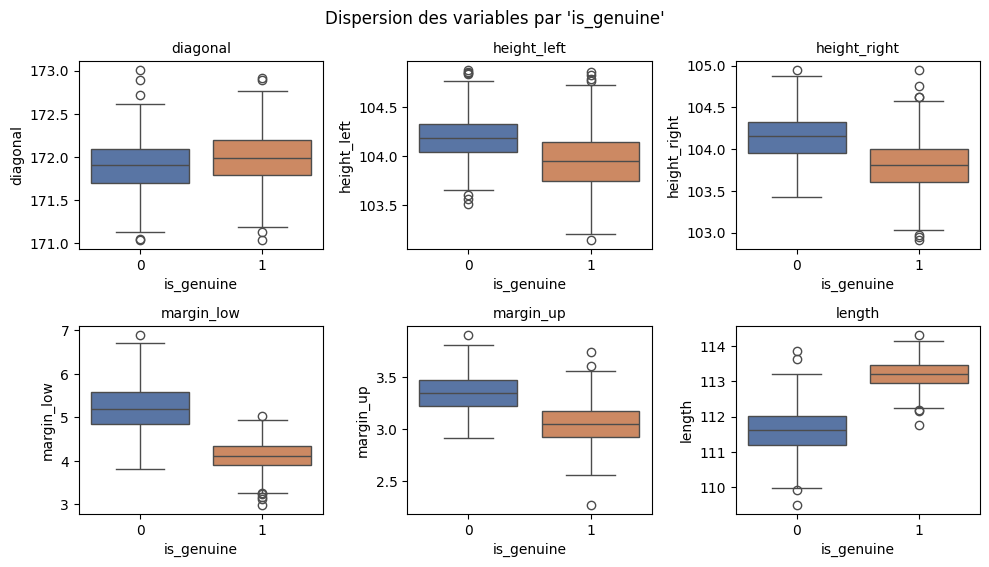

In [57]:
# Sélectionner les variables numériques
list_variables = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

# Création de la figure avec une grille (ici 3 lignes x 3 colonnes pour 5 plots)
fig, axs = plt.subplots(3, 3, figsize=(10, 8))
axs = axs.flatten()

# Itérer sur chaque variable de list_variables et tracer le boxplot séparé par 'is_genuine'
for i, column in enumerate(list_variables):
    # Ici, on met 'is_genuine' en x pour séparer les groupes, et la variable étudiée en y.
    sns.boxplot(x='is_genuine', y=column, data=df, ax=axs[i], palette='deep')
    axs[i].set_title(column, size=10)
    axs[i].set_xlabel("is_genuine")
    axs[i].set_ylabel(column)

# Masquer les subplots non utilisés
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

fig.suptitle("Dispersion des variables par 'is_genuine'")
plt.tight_layout()
plt.show()


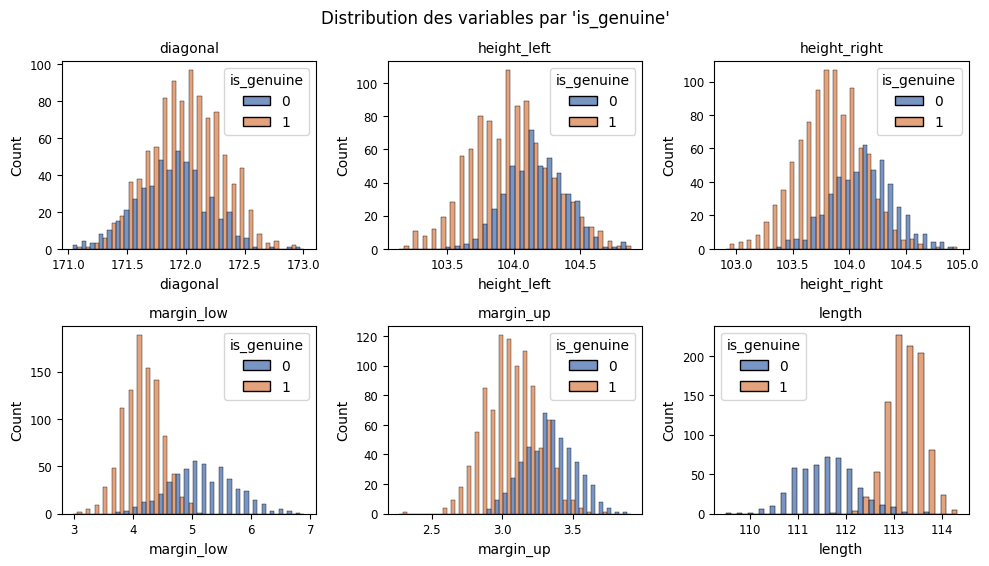

In [58]:
# Création de la figure avec une grille de subplots (3 lignes x 3 colonnes pour 5 plots)
fig, axs = plt.subplots(3, 3, figsize=(10, 8))
axs = axs.ravel()

# Itérer sur chaque variable de list_variables et tracer son histogramme avec 'is_genuine'
for i, column in enumerate(list_variables):
    sns.histplot(data=df, x=column, hue="is_genuine", bins="auto", 
                 ax=axs[i], palette="deep", multiple="dodge")
    axs[i].set_title(column, size=10)
    axs[i].tick_params(axis='both', which='both', labelsize=8.5)

# Masquer les subplots inutilisés
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

fig.suptitle("Distribution des variables par 'is_genuine'")
plt.tight_layout()
plt.show()


In [59]:
def pairplot_correlation(df, hue=None):
    '''
    Trace les paires de variables et affiche les coefficients de corrélation.
    Paramètres :
    - df = DataFrame source ;
    - hue = variable à différencier (couleur) sur le graphique.
    '''
    # Calcule la matrice de corrélation
    corr_matrix = df.select_dtypes(include='number').corr()

    # Définit le nombre de sous-graphiques et la taille du graphique
    fig, axs = plt.subplots(
        corr_matrix.shape[0], corr_matrix.shape[1], 
        figsize=((corr_matrix.shape[0]*1.4), (corr_matrix.shape[1]*1.2))
    )

    # Boucle sur les lignes et colonnes de la matrice de corrélation
    for i, idx in enumerate(corr_matrix.index):
        for j, col in enumerate(corr_matrix.columns):
            # Affiche le nom des variables
            if i == j:
                axs[i, j].text(x=0.5, y=0.5, s=idx, ha='center', va='center',
                               fontweight='bold')

            # Affiche les coefficients de corrélation
            elif i < j:
                corr_coeff = corr_matrix.loc[idx, col]
                axs[i, j].text(x=0.5, y=0.5, s=f'corr =\n{corr_coeff:.3}',
                               ha='center', va='center')

            # Trace les graphiques
            elif i > j:
                # Trace en fonction de la variable indiquée dans 'hue'
                if hue != None:
                    hue = hue
                    for value in df[hue].unique():
                        axs[i, j].scatter(
                            x=idx, y=col, data=df.loc[df[hue] == value], 
                            marker='.', alpha=0.65, edgecolors='k'
                        )
                        axs[i, j].tick_params(axis='both', labelsize=6.5)

                # Trace sans différenciation
                elif hue == None:
                    axs[i, j].scatter(x=idx, y=col, data=df, marker='.',
                                      edgecolors='k', alpha=0.65)
                    axs[i, j].tick_params(axis='both', labelsize=6.5)
                    
            axs[i, j].xaxis.set_major_locator(ticker.NullLocator())
            axs[i, j].yaxis.set_major_locator(ticker.NullLocator())

    fig.suptitle('Paires de variables et coefficients de corrélation')

    fig.tight_layout()

    plt.show()

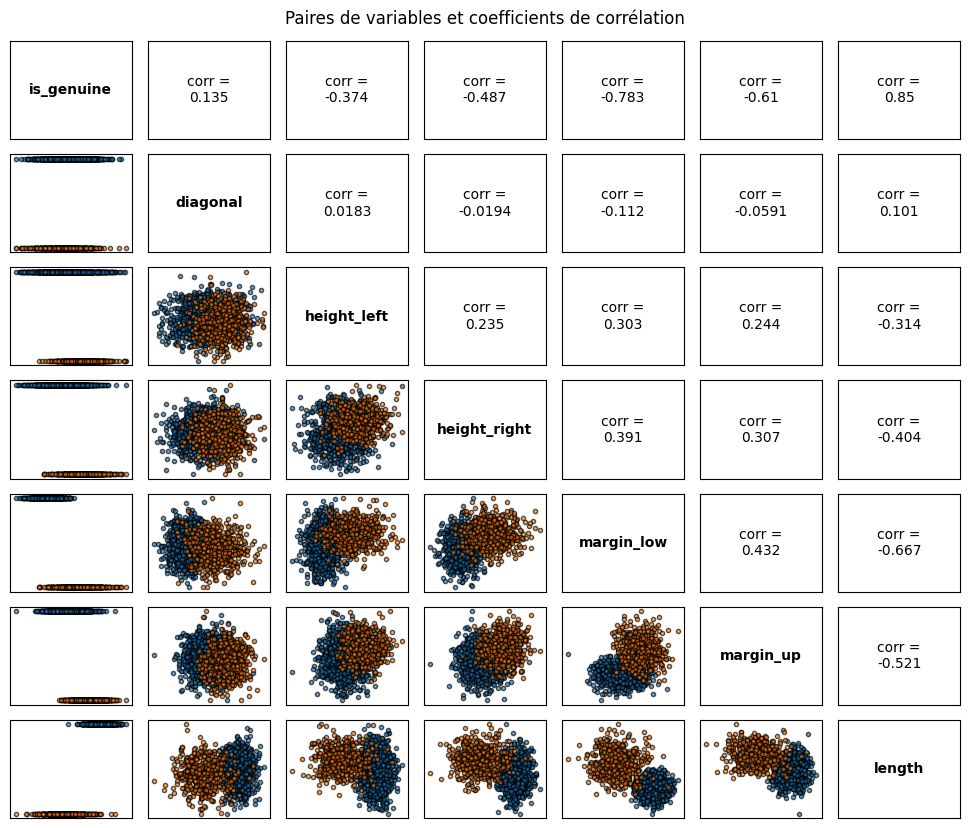

In [60]:
# Trace les variables quantitatives par paires
pairplot_correlation(df, hue='is_genuine')

## Résumé de l'analyse exploratoire des données pour la prédiction

**lignes et colonnes :** 1463 lignes, 7 colonnes  

**variable cible :** 'is_genuine', 971 *vrais* billets et 492 *faux* billets

**analyse des valeurs manquantes :** Pas de valeur manquante  

### **Distribution / Dispersion:**  

Les différences dimensionnelles entre les vrais et les faux billets sont plus visibles : `diagonal` est assez similaire  
tandis que `margin_low` et `length` sont très différentes.  

### **Corrélations:**  

On visualise assez bien deux groupes distincts, notamment pour les variables les plus corrélées entre elles.
 


Avant de commencer notre `Régression logistique`, nous allons procéder au test statistique de Kruskal-Wallis qui nous indique si nos variables quantitatives  
sont statistiquement significatives pour un modèle en vue de la détermination d'une variable catégorielle. 

In [61]:
# Initialiser les listes pour stocker les résultats
var_names = []
kw_stats = []
p_values = []

# Parcourir toutes les variables numériques
for var in list_variables:
    # Calculer les groupes de valeurs
    groups = [df[df['is_genuine'] == 0][var], df[df['is_genuine'] == 1][var]]
    # Appliquer le test de Kruskal-Wallis
    kw_stat, p = stats.kruskal(*groups)
    # Ajouter les résultats aux listes correspondantes
    var_names.append(var)
    kw_stats.append(kw_stat)
    p_values.append(p)

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame({
    'Variable': var_names,
    'Kruskal-Wallis': kw_stats,
    'P-valeur': p_values
})

# Trier le DataFrame par ordre croissant de p-valeur
results_df.sort_values(by='P-valeur', inplace=True)

# Afficher le tableau des résultats
print(results_df)

       Variable  Kruskal-Wallis       P-valeur
5        length      916.909842  2.069484e-201
3    margin_low      828.742803  3.040847e-182
4     margin_up      549.894892  1.326952e-121
2  height_right      355.690730   2.443040e-79
1   height_left      221.402151   4.472424e-50
0      diagonal       24.912232   6.000051e-07


Grâce au test KW, on remarque que les variables quantitatives statistiquement significatives (p-valeur < 5%) sont dans l'ordre, length, margin_low, margin_up...

## **1er modèle : Regression logistique**

La régression logistique est une méthode de classification supervisée dont l'objectif est de modéliser les relations entre une variable binaire  
en fonction de variables généralement quantitatives. Il s’agit d’un modèle linéaire généralisé utilisant une fonction logistique comme fonction de lien. 

Nous utiliserons en 1ère étape `statsmodels`.  
Nous calculons le VIF pour vérifier la multicolinéarité.

In [62]:
# Définir les variables explicatives pour la classification.
# Ici, nous utilisons les 6 dimensions géométriques, y compris margin_low (qui est désormais complétée).
features_classif = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

# Définir la cible
target = "is_genuine"

# Création des ensembles X et y
X = df[features_classif]
y = df[target]

# Ajouter une constante pour l'interception
X = sm.add_constant(X)

# Séparation en ensembles d'entraînement et de test (stratification pour respecter la répartition des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Créer le modèle de régression logistique
logit_model = sm.Logit(y_train, X_train)

# Calculer le VIF pour chaque variable explicative
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif["features"] = X_train.columns

# Afficher les résultats
print(vif)

      VIF Factor      features
0  600498.821352         const
1       1.017223      diagonal
2       1.153383   height_left
3       1.272002  height_right
4       1.888770    margin_low
5       1.417640     margin_up
6       2.086698        length


Les résultats du VIF étant inférieurs à 5, nous pouvons conclure que nous n'avons pas de multicolinéarité.

In [63]:
# Ajuster le modèle aux données d'apprentissage
result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.026726
         Iterations 13


In [64]:
# Afficher le résumé des résultats de la régression
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:             is_genuine   No. Observations:                 1170
Model:                          Logit   Df Residuals:                     1163
Method:                           MLE   Df Model:                            6
Date:                Tue, 08 Apr 2025   Pseudo R-squ.:                  0.9581
Time:                        08:04:25   Log-Likelihood:                -31.269
converged:                       True   LL-Null:                       -746.78
Covariance Type:            nonrobust   LLR p-value:                4.628e-306
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -124.7552    267.521     -0.466      0.641    -649.087     399.577
diagonal        -0.1852      1.311     -0.141      0.888      -2.755       2.385
height_left     -1.2439      1.240     -1.00

LLR p-value étant inférieur à 5%, nous pouvons considérer que notre modèle en général est significatif.  
Les coefficients et les p-value de chaque variable nous indiquent si ces coefficients sont statistiquement significatifs sur notre modèle.  
On peut remarquer que les coefficients de  `diagonal` et `height_left`, ne sont pas statistiquement significatifs sur le modèle.  
Nous décidons donc de supprimer ces 2 variables à notre modèle.

In [65]:
# Définir les variables explicatives pour la classification.
# Ici, nous utilisons les 4 dimensions géométriques sélectionnées
features_classif = ["margin_low", "margin_up", "length", "height_right"]

# Définir la cible
target = "is_genuine"

# Création des ensembles X et y
X = df[features_classif]
y = df[target]

import statsmodels.api as sm

# Ajouter une constante pour l'interception
X = sm.add_constant(X)

# Séparation en ensembles d'entraînement et de test (stratification pour respecter la répartition des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Créer le modèle de régression logistique
logit_model = sm.Logit(y_train, X_train)

# Calculer le VIF pour chaque variable explicative
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif["features"] = X_train.columns

# Afficher les résultats
print(vif)

      VIF Factor      features
0  186457.604274         const
1       1.862124    margin_low
2       1.412533     margin_up
3       2.054069        length
4       1.255721  height_right


In [66]:
# Ajuster le modèle aux données d'apprentissage
result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.027169
         Iterations 13


In [67]:
# Afficher le résumé des résultats de la régression
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:             is_genuine   No. Observations:                 1170
Model:                          Logit   Df Residuals:                     1165
Method:                           MLE   Df Model:                            4
Date:                Tue, 08 Apr 2025   Pseudo R-squ.:                  0.9574
Time:                        08:04:25   Log-Likelihood:                -31.787
converged:                       True   LL-Null:                       -746.78
Covariance Type:            nonrobust   LLR p-value:                2.167e-308
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -238.3735    158.180     -1.507      0.132    -548.401      71.654
margin_low      -6.3225      1.063     -5.948      0.000      -8.406      -4.239
margin_up      -10.5384      2.519     -4.18

Maintenant, notre modèle est significatif et les coefficients des variables sélectionnées sont statistiquement significatifs.

Pour la suite du développement de notre modèle, nous utiliserons la bibliothèque de `scikit-learn`.  
Le module `sklearn.metrics` nous permet de calculer différentes métriques qui nous aideront à la comparaison de nos modèles.  

|Métrique              |Définition                                                                                            |
|:---------------------|:-----------------------------------------------------------------------------------------------------|
|*accuracy_exactitude* |Mesure le taux de prédictions correctes sur l'ensemble des individus positifs et négatifs             |
|*precision_précision* |Mesure la capacité du modèle à détecter l’ensemble des individus d'une classe en particulier          |
|*recall_rappel*       |Mesure la capacité du modèle à ne pas faire d’erreur lors d’une prédiction d'une classe en particulier|
|*f1-score*            |Le F1-score permet de résumer les valeurs de *precision* et de *recall* en une seule métrique         |

In [68]:
# Définir les variables explicatives pour la classification.
# Ici, nous utilisons les 4 dimensions géométriques.
features_classif = ["margin_low", "margin_up", "length", "height_right"]

# Définir la cible
target = "is_genuine"

# Création des ensembles X et y
X = df[features_classif]
y = df[target]

# Séparation en ensembles d'entraînement et de test (stratification pour respecter la répartition des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialisation du modèle
logreg = LogisticRegression()

# Entraînement du modèle
logreg.fit(X_train, y_train)

LogisticRegression()

Performance sur la base apprentissage
Train Accuracy :  0.9897435897435898
Train Confusion matrix : 
 [[385   8]
 [  4 773]]
Train Classification report : 
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       393
           1       0.99      0.99      0.99       777

    accuracy                           0.99      1170
   macro avg       0.99      0.99      0.99      1170
weighted avg       0.99      0.99      0.99      1170

Performance sur la base test
Test Accuracy :  0.9897610921501706
Test Classification report : 
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        99
           1       0.98      1.00      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.98      0.99       293
weighted avg       0.99      0.99      0.99       293



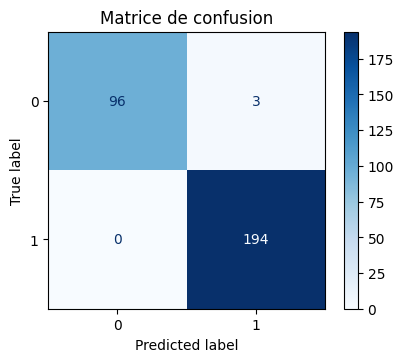


Tableau comparatif des métriques (avec focus sur la détection des faux billets) :
                        Exactitude    Précision       Rappel     F1-Score
Régression Logistique  0.989761092  1.000000000  0.969696970  0.984615385


In [69]:
# Prédictions sur l'ensemble d'entraînement
y_train_pred = logreg.predict(X_train)

# Évaluation des performances sur l'ensemble d'entraînement
train_accuracy = accuracy_score(y_train, y_train_pred)
train_confusion = confusion_matrix(y_train, y_train_pred)
train_classification = classification_report(y_train, y_train_pred)

print('Performance sur la base apprentissage')
print('Train Accuracy : ', train_accuracy)
print('Train Confusion matrix : \n', train_confusion)
print('Train Classification report : \n', train_classification)

# Prédictions sur l'ensemble de test
y_test_pred = logreg.predict(X_test)

# Évaluation des performances sur l'ensemble de test
print('Performance sur la base test')
test_accuracy = accuracy_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
test_classification = classification_report(y_test, y_test_pred)

print('Test Accuracy : ', test_accuracy)
# print('Test Confusion matrix : \n', test_confusion)
print('Test Classification report : \n', test_classification)

# Affichage de la matrice de confusion pour le modèle
fig, ax = plt.subplots(figsize=(4.8, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap='Blues')
ax.set_title("Matrice de confusion")
plt.show()

# Calcul des métriques ciblées sur la classe "0" (faux billets)
# Nous extrayons les métriques pour la classe 0 à partir des fonctions de scoring
precision_counterfeit = round(precision_score(y_test, y_test_pred, pos_label=0), 9)
recall_counterfeit = round(recall_score(y_test, y_test_pred, pos_label=0), 9)
f1_counterfeit = round(f1_score(y_test, y_test_pred, pos_label=0), 9)

# Construction d'un DataFrame des résultats (arrondis à 9 décimales)
df_results = pd.DataFrame({
    "Exactitude": [f"{test_accuracy:.9f}"],
    "Précision": [f"{precision_counterfeit:.9f}"],
    "Rappel": [f"{recall_counterfeit:.9f}"],
    "F1-Score": [f"{f1_counterfeit:.9f}"]
}, index=["Régression Logistique"])

print("\nTableau comparatif des métriques (avec focus sur la détection des faux billets) :")
print(df_results)

La matrice de confusion permet de décrire les performances du modèle, sachant que nous avons sélectionné la classe positive [0] soit *faux* billets:
* Les **vrais positifs** : pour *96 billets (faux)*, le modèle prédit *correctement* qu'ils sont *faux*. (96 observations réellement à 0 et prédites à 0)
* Les **faux positifs** : pour *0 billets (vrais)*, le modèle prédit *à tort* qu'ils sont *faux*. (0 observations réellement à 1 et prédites à 0)
* Les **faux négatifs** : pour *3 billets (faux)*, le modèle prédit *à tort* qu'ils sont *vrais*. (3 observations réellement à 0 et prédites à 1)
* Les **vrais négatifs** : pour *194 billets (vrais)*, le modèle prédit *correctement* qu'ils sont *vrais*. (194 observations réellement à 1 et prédites à 1)

#### Optimisation avec `GridSearchCV`

Essayons d'améliorer notre modèle en optimisant le choix des paramètres de la régression grâce à `GridSearchCV`.  

`GridSearchCV` effectue également une validation croisée qui exécute le processus de modélisation sur différents sous-ensembles de données  
afin d'obtenir plusieurs mesures de la qualité du modèle et ainsi s'assurer de sa qualité.

In [70]:
# Définir la grille des hyperparamètres à tester
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear supporte l1 et l2
}

# Initialisation du modèle de régression logistique
logreg_base = LogisticRegression(random_state=42, max_iter=1000)

# Configuration de GridSearchCV avec validation croisée (5 plis)
grid_search_logreg = GridSearchCV(estimator=logreg_base,
                                  param_grid=param_grid_logreg,
                                  cv=5,
                                  scoring='accuracy',
                                  n_jobs=-1)

# Entraînement avec GridSearchCV sur l'ensemble d'entraînement
grid_search_logreg.fit(X_train, y_train)

# Affichage des meilleurs paramètres et du score de validation
print("Meilleurs paramètres trouvés :", grid_search_logreg.best_params_)
# print(f"\n✅ Précision du modèle Régression Logistique Optimisée : {grid_search_logreg.best_score_:.9f}")

Meilleurs paramètres trouvés : {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


Performance sur la base apprentissage
Train Accuracy :  0.9914529914529915
Train Confusion matrix : 
 [[386   7]
 [  3 774]]
Train Classification report : 
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       393
           1       0.99      1.00      0.99       777

    accuracy                           0.99      1170
   macro avg       0.99      0.99      0.99      1170
weighted avg       0.99      0.99      0.99      1170

Performance sur la base test
Test Accuracy :  0.9863481228668942
Test Classification report : 
               precision    recall  f1-score   support

           0       0.99      0.97      0.98        99
           1       0.98      0.99      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.98      0.98       293
weighted avg       0.99      0.99      0.99       293



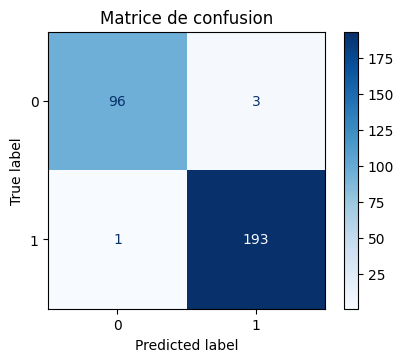


Tableau comparatif des métriques (avec focus sur la détection des faux billets) :
                                       Exactitude    Précision       Rappel  \
Régression Logistique                 0.989761092  1.000000000  0.969696970   
Régression Logistique + GridSearchCV  0.986348123  0.989690722  0.969696970   

                                         F1-Score  
Régression Logistique                 0.984615385  
Régression Logistique + GridSearchCV  0.979591837  


In [71]:
# Récupération du meilleur modèle optimisé
best_logreg = grid_search_logreg.best_estimator_

# Prédictions sur l'ensemble d'entraînement
y_train_pred = best_logreg.predict(X_train)

# Évaluation des performances sur l'ensemble d'entraînement
train_accuracy = accuracy_score(y_train, y_train_pred)
train_confusion = confusion_matrix(y_train, y_train_pred)
train_classification = classification_report(y_train, y_train_pred)

print('Performance sur la base apprentissage')
print('Train Accuracy : ', train_accuracy)
print('Train Confusion matrix : \n', train_confusion)
print('Train Classification report : \n', train_classification)

# Prédictions sur l'ensemble de test
y_test_pred = best_logreg.predict(X_test)

# Évaluation des performances sur l'ensemble de test
print('Performance sur la base test')
test_accuracy = accuracy_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
test_classification = classification_report(y_test, y_test_pred)

print('Test Accuracy : ', test_accuracy)
# print('Test Confusion matrix : \n', test_confusion)
print('Test Classification report : \n', test_classification)

# Affichage de la matrice de confusion pour le modèle
fig, ax = plt.subplots(figsize=(4.8, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap='Blues')
ax.set_title("Matrice de confusion")
plt.show()

# Calcul des métriques ciblées sur la classe "0" (faux billets)
# Nous extrayons les métriques pour la classe 0 à partir des fonctions de scoring
precision_counterfeit = round(precision_score(y_test, y_test_pred, pos_label=0), 9)
recall_counterfeit = round(recall_score(y_test, y_test_pred, pos_label=0), 9)
f1_counterfeit = round(f1_score(y_test, y_test_pred, pos_label=0), 9)

# Construction d'un DataFrame des résultats (arrondis à 9 décimales)
new_row = pd.DataFrame({
    "Exactitude": [f"{test_accuracy:.9f}"],
    "Précision": [f"{precision_counterfeit:.9f}"],
    "Rappel": [f"{recall_counterfeit:.9f}"],
    "F1-Score": [f"{f1_counterfeit:.9f}"]
}, index=["Régression Logistique + GridSearchCV"])

# Utilisation de pd.concat() pour ajouter la nouvelle ligne
df_results = pd.concat([df_results, new_row], ignore_index=False)

print("\nTableau comparatif des métriques (avec focus sur la détection des faux billets) :")
print(df_results)

#### Oversampling

L'oversampling est une technique de rééchantillonnage utilisée pour gérer les ensembles de données déséquilibrés en augmentant le nombre d'échantillons de la classe minoritaire.  
Cela peut être fait en dupliquant les échantillons existants ou en générant de nouveaux échantillons synthétiques à partir des données existantes, par exemple en utilisant des méthodes  
telles que SMOTE (Synthetic Minority Over-sampling Technique) ou ADASYN (Adaptive Synthetic Sampling).

* Avantages  
  - Améliore la performance du modèle sur la classe minoritaire en augmentant la quantité d'informations disponibles pour l'apprentissage.  
  - Réduit le biais envers la classe majoritaire, ce qui peut améliorer la précision globale du modèle.  
  - Facilite la découverte de modèles significatifs dans les données en permettant aux algorithmes d'apprentissage d'explorer plus en profondeur la structure de la classe minoritaire.  
* Inconvénients  
  - Peut entraîner un surapprentissage, car les échantillons dupliqués ou synthétiques peuvent augmenter la complexité du modèle sans apporter d'informations nouvelles.  
  - Augmente la taille de l'ensemble de données, ce qui peut augmenter les temps d'apprentissage et de prédiction.

In [72]:
# Importer les bibliothèques nécessaires
from imblearn.over_sampling import RandomOverSampler

# Initialiser l'objet RandomOverSampler
ros = RandomOverSampler(sampling_strategy=1, random_state=42)

# Appliquer l'oversampling sur les données d'apprentissage
X_train_oversampled, y_train_oversampled = ros.fit_resample(X_train, y_train)

In [73]:
# Créer un nouveau DataFrame avec les données oversampled
bankdata_oversampled = pd.concat([X_train_oversampled, y_train_oversampled], axis=1)

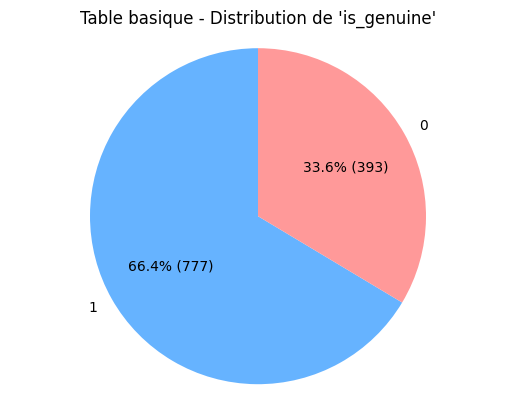

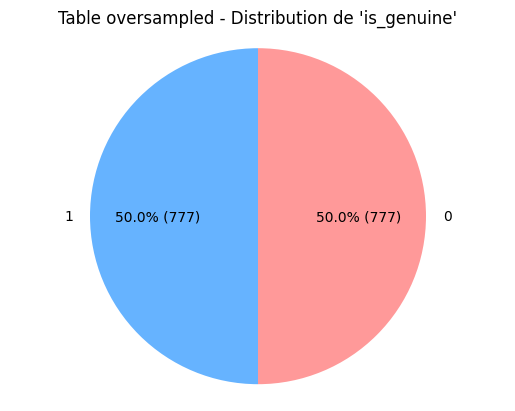

In [74]:
# Fonction pour créer un pie chart avec les proportions et les nombres
def plot_pie_chart(y, title):
    labels = ['1', '0']
    sizes = y.value_counts().values
    colors = ['#66b3ff', '#ff9999']
    
    # Modifier le format des labels pour inclure les proportions et les nombres
    def autopct_format(pct, all_values):
        absolute = int(round(pct / 100 * sum(all_values)))
        return f"{pct:.1f}% ({absolute})"

    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels, colors=colors, autopct=lambda pct: autopct_format(pct, sizes), startangle=90)
    ax.axis('equal')  # Pour assurer que le diagramme est bien rond
    plt.title(title)
    plt.show()

# Créer un pie chart pour la table basique
plot_pie_chart(y_train, "Table basique - Distribution de 'is_genuine'")

# Créer un pie chart pour la table oversampled
plot_pie_chart(y_train_oversampled, "Table oversampled - Distribution de 'is_genuine'")

In [75]:
# Entraînement du modèle
logreg_oversampled = logreg.fit(X_train_oversampled, y_train_oversampled)

Performance sur la base apprentissage
Train Accuracy :  0.9903474903474904
Train Confusion matrix : 
 [[767  10]
 [  5 772]]
Train Classification report : 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       777
           1       0.99      0.99      0.99       777

    accuracy                           0.99      1554
   macro avg       0.99      0.99      0.99      1554
weighted avg       0.99      0.99      0.99      1554

Performance sur la base test
Test Accuracy :  0.9829351535836177
Test Classification report : 
               precision    recall  f1-score   support

           0       0.98      0.97      0.97        99
           1       0.98      0.99      0.99       194

    accuracy                           0.98       293
   macro avg       0.98      0.98      0.98       293
weighted avg       0.98      0.98      0.98       293



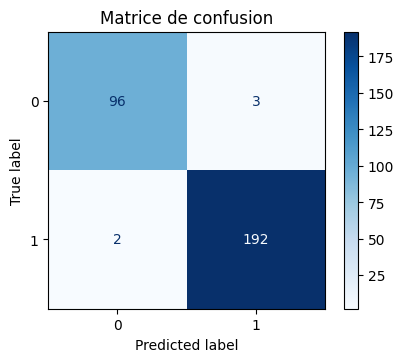


Tableau comparatif des métriques (avec focus sur la détection des faux billets) :
                                       Exactitude    Précision       Rappel  \
Régression Logistique                 0.989761092  1.000000000  0.969696970   
Régression Logistique + GridSearchCV  0.986348123  0.989690722  0.969696970   
Régression Logistique + Oversampling  0.982935154  0.979591837  0.969696970   

                                         F1-Score  
Régression Logistique                 0.984615385  
Régression Logistique + GridSearchCV  0.979591837  
Régression Logistique + Oversampling  1.000000000  


In [76]:
# Prédictions sur l'ensemble d'entraînement
y_train_pred = logreg_oversampled.predict(X_train_oversampled)

# Évaluation des performances sur l'ensemble d'entraînement
train_accuracy = accuracy_score(y_train_oversampled, y_train_pred)
train_confusion = confusion_matrix(y_train_oversampled, y_train_pred)
train_classification = classification_report(y_train_oversampled, y_train_pred)

print('Performance sur la base apprentissage')
print('Train Accuracy : ', train_accuracy)
print('Train Confusion matrix : \n', train_confusion)
print('Train Classification report : \n', train_classification)

# Prédictions sur l'ensemble de test
y_test_pred = logreg_oversampled.predict(X_test)

# Évaluation des performances sur l'ensemble de test
print('Performance sur la base test')
test_accuracy = accuracy_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
test_classification = classification_report(y_test, y_test_pred)

print('Test Accuracy : ', test_accuracy)
# print('Test Confusion matrix : \n', test_confusion)
print('Test Classification report : \n', test_classification)

# Affichage de la matrice de confusion pour le modèle
fig, ax = plt.subplots(figsize=(4.8, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap='Blues')
ax.set_title("Matrice de confusion")
plt.show()

# Calcul des métriques ciblées sur la classe "0" (faux billets)
# Nous extrayons les métriques pour la classe 0 à partir des fonctions de scoring
precision_counterfeit = round(precision_score(y_test, y_test_pred, pos_label=0), 9)
recall_counterfeit = round(recall_score(y_test, y_test_pred, pos_label=0), 9)
f1_counterfeit = round(f1_score(y_test, y_test_pred, pos_label=0), 1)

## Construction d'un DataFrame des résultats (arrondis à 9 décimales)
new_row = pd.DataFrame({
    "Exactitude": [f"{test_accuracy:.9f}"],
    "Précision": [f"{precision_counterfeit:.9f}"],
    "Rappel": [f"{recall_counterfeit:.9f}"],
    "F1-Score": [f"{f1_counterfeit:.9f}"]
}, index=["Régression Logistique + Oversampling"])

# Utilisation de pd.concat() pour ajouter la nouvelle ligne
df_results = pd.concat([df_results, new_row], ignore_index=False)

print("\nTableau comparatif des métriques (avec focus sur la détection des faux billets) :")
print(df_results)

## **2ème modèle : K-Means**

La seconde méthode que nous allons utiliser est la **classification k-means**. C'est un algorithme de classification qui regroupe les individus en cherchant à minimiser l'inertie intraclasse de chaque groupe.  
Pour cela, l'algorithme utilise les centres de gravité (centroïdes) des groupes. Au départ, les centroïdes sont placés aléatoirement puis, ils sont recaculés à chaque itération  
jusqu'à ce que les résultats de l'algorithme convergent.

Avant de tester le modèle K-Means (non-supervisé), nous allons réaliser une Analyse en Composantes Principales sur nos données normalisées.

### Analyse en Composantes Principales

In [77]:
# Définir les variables explicatives pour la classification.
# Ici, nous utilisons les 6 dimensions géométriques.
features_classif = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

# Définir la cible
target = "is_genuine"

# Création des ensembles X et y
X = df[features_classif]
y = df[target]

# Séparation en ensembles d'entraînement et de test (stratification pour respecter la répartition des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Standardisation des données de classification
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
pca = PCA(n_components=6)
pca.fit(X_train_scaled)

PCA(n_components=6)

In [79]:
# create data
components = X_train_scaled.shape[1]
scree = (pca.explained_variance_ratio_*100).round(2)
scree_cum = scree.cumsum().round()
a_list = range(1, components+1)
list(a_list)

[1, 2, 3, 4, 5, 6]

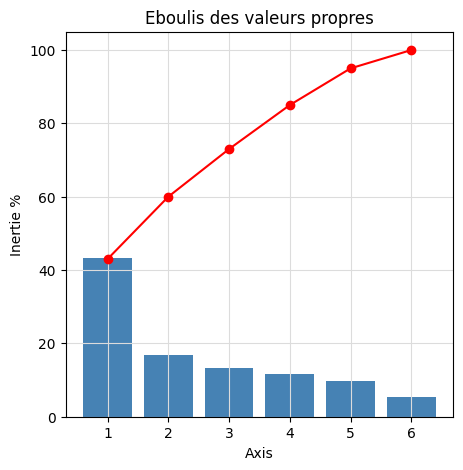

In [80]:
# plot data
plt.figure(figsize=(5, 5))
plt.bar(a_list, scree, color="steelblue")
plt.plot(a_list, scree_cum, color='red', marker='o')
plt.xlabel("Axis")
plt.ylabel("Inertie %")
plt.title("Eboulis des valeurs propres")
plt.grid(axis='both', color='gainsboro')
plt.savefig("eboulis.png", bbox_inches='tight')
plt.show(block=False)

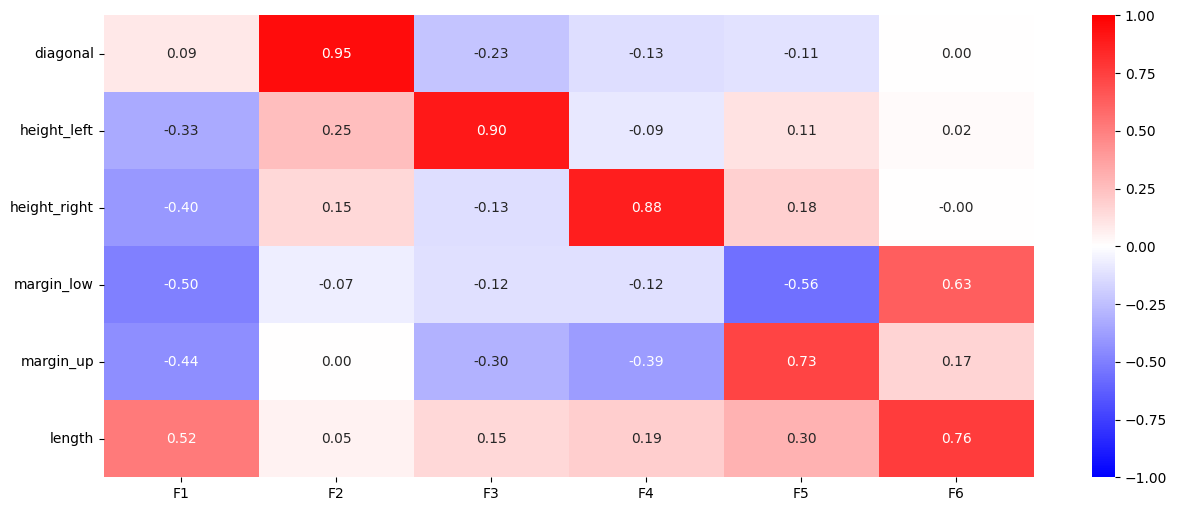

In [81]:
# create components dataframe
acp_components = pd.DataFrame(pca.components_)
acp_components.columns = features_classif
acp_components.index = [f"F{i}" for i in a_list]

# plot heatmap
fig, ax = plt.subplots(figsize=(15, 6))
acp_heatmap = sns.heatmap(acp_components.T.round(2), vmin=-1, vmax=1, annot=True, cmap="bwr", fmt="0.2f")
plt.savefig("acp_heatmap.png", bbox_inches='tight', pad_inches=0.5)

In [82]:
def correlation_graph(pca, 
                      x_y, 
                      features) : 
    """Affiche le graphe des correlations

    Positional arguments : 
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y 
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 10))

    # Pour chaque composante : 
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0, 
                pca.components_[x, i],  
                pca.components_[y, i],  
                head_width=0.07,
                head_length=0.07, 
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])
        
    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle 
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

In [83]:
x_y = (0,1)
x_y

(0, 1)

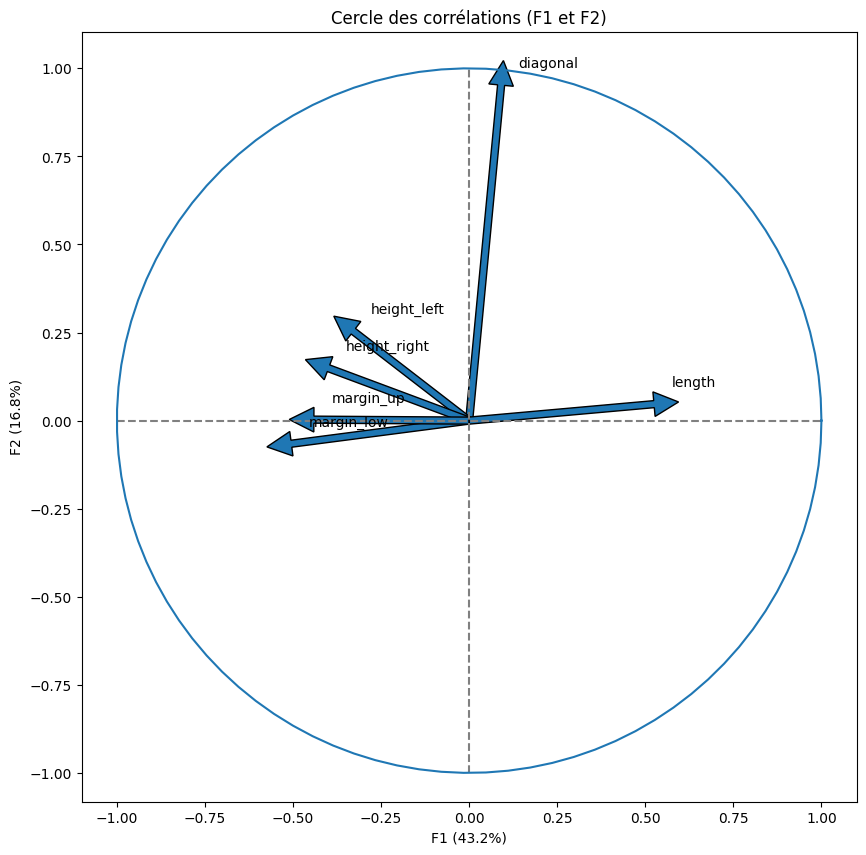

In [84]:
correlation_graph(pca, x_y, features_classif)

In [85]:
X_proj = pca.transform(X_train_scaled)
X_proj[:5]

array([[-2.08074276, -0.36744722,  0.63060209,  0.02576135, -1.84665453,
         0.54867057],
       [-3.01162805, -0.39137987, -0.36527341, -0.75248558, -0.42192039,
         0.22957886],
       [ 0.9402135 ,  1.10574077, -0.06906855,  0.87587315,  0.93317757,
         0.36178545],
       [-1.60445378, -1.35918067, -0.93224572, -0.25938977,  0.7103242 ,
        -0.58675648],
       [ 0.35665185, -0.78963452,  0.40098272, -0.79480474,  3.20292441,
         0.57519129]])

In [86]:
def display_factorial_planes(   X_projected, 
                                x_y, 
                                pca=None, 
                                labels = None,
                                clusters=None, 
                                alpha=1,
                                figsize=[10,8], 
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments : 
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments : 
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8] 
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize: 
        figsize = (7,6)

    # On gère les labels
    if  labels is None : 
        labels = []
    try : 
        len(labels)
    except Exception as e : 
        raise e

    # On vérifie la variable axis 
    if not len(x_y) ==2 : 
        raise AttributeError("2 axes sont demandées")   
    if max(x_y )>= X_.shape[1] : 
        raise AttributeError("la variable axis n'est pas bonne")   

    # on définit x et y 
    x, y = x_y

    # Initialisation de la figure       
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters
 
    # Les points    
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha, 
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe 
    if pca : 
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else : 
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y 
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) : 
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center') 

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()

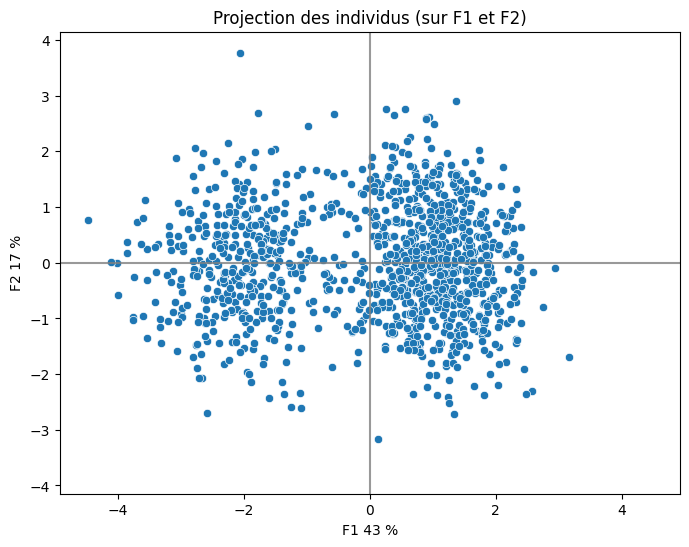

In [87]:
x_y = [0,1]
display_factorial_planes(X_proj, x_y, pca, figsize=(8,6), marker="o")

In [88]:
pca = PCA(n_components=2)
X_proj = pca.fit_transform(X_train_scaled)

Pour choisir le nombre optimal de *clusters* nous allons nous appuyer sur la **méthode du coude** dans laquelle nous allons calculer l'inertie intraclasse en fonction du nombre  
de groupes. On cherchera alors à déterminer à partir de quand l'augmentation du nombre de *clusters* n'a plus un impact significatif sur la diminution de l'inertie.  

Nous utiliserons également le **score de silhouette**.

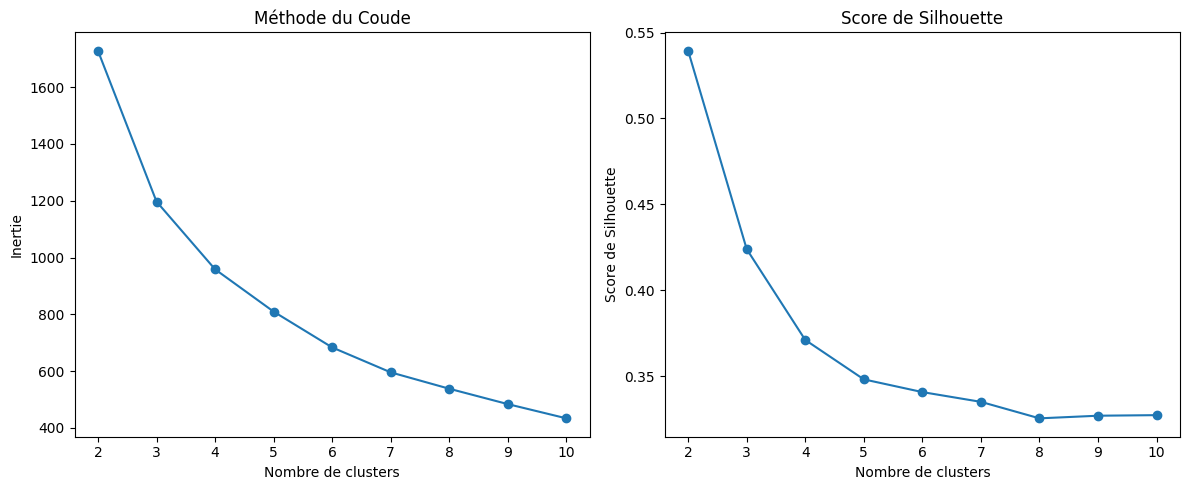

In [89]:
from sklearn import metrics

# On utilise les données d'entraînement pour la classification : X_train
n_clusters_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in n_clusters_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_proj)
    inertias.append(km.inertia_)
    silhouette_avg = metrics.silhouette_score(X_proj, km.labels_)
    silhouette_scores.append(silhouette_avg)

# Affichage du graphique de la méthode du coude et du score de silhouette
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(n_clusters_range, inertias, marker='o')
plt.title("Méthode du Coude")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")

plt.subplot(1, 2, 2)
plt.plot(n_clusters_range, silhouette_scores, marker='o')
plt.title("Score de Silhouette")
plt.xlabel("Nombre de clusters")
plt.ylabel("Score de Silhouette")

plt.tight_layout()
plt.show()


La cassure selon la **méthode du Coude** n'est pas flagrante. Néanmoins, le **score de silhouette** nous indique que le nombre optimal de clusters se situe à 2.  
Sachant que nous devons classer les billets en 2 catégories, il n'y a pas de raison de choisir plus que 2 clusters.

In [90]:
# Initialise le nombre de clusters
n_clusters = 2

# Effectue le clustering
clustering = KMeans(n_clusters=n_clusters, n_init='auto', init='random',
                    random_state=0)
clustering.fit(X_proj)

KMeans(init='random', n_clusters=2, random_state=0)

Nous créons un DataFrame avec les clusters définis par KMeans.

In [91]:
# Créer un DataFrame avec les composantes issues de l'ACP
df_train_proj = pd.DataFrame(X_proj, columns=["F1", "F2"])
# Ajouter la variable cible 'is_genuine' (assurez-vous que l'index correspond bien)
df_train_proj["is_genuine"] = y_train.reset_index(drop=True)
# Ajouter les labels de cluster obtenus par K-Means
df_train_proj["cluster"] = clustering.labels_

In [92]:
df_train_proj

,F1,F2,is_genuine,cluster
0,-2.080743,-0.367447,0,0
1,-3.011628,-0.391380,0,0
2,0.940214,1.105741,1,1
3,-1.604454,-1.359181,0,0
4,0.356652,-0.789635,1,1
...,...,...,...,...
1165,-1.497665,-1.180558,0,0
1166,1.281173,-1.298475,1,1
1167,-1.325334,1.418732,0,0
1168,0.381432,0.474511,1,1


Pour déterminer à quelle classe (vrai/faux) appartient le cluster obtenu, nous calculons la valeur la plus fréquente attribuée au groupe.  
Cette méthode s'appelle le `vote majoritaire`.


In [93]:
# Pour chaque cluster, déterminer la classe majoritaire (vote majoritaire)
cluster_mapping = df_train_proj.groupby("cluster")["is_genuine"].agg(lambda x: x.mode()[0])
print("Mapping des clusters aux classes réelles :")
print(cluster_mapping)

Mapping des clusters aux classes réelles :
cluster
0    0
1    1
Name: is_genuine, dtype: int64


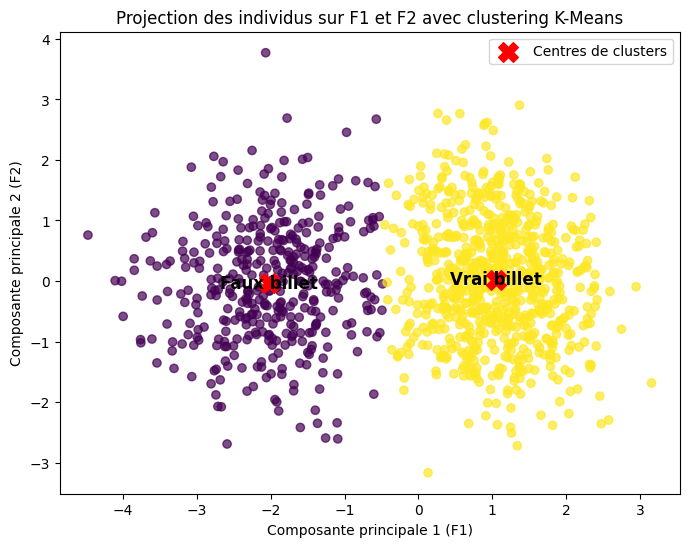

In [94]:
# Exemple de mapping (ceci doit être calculé en fonction de vos données d'entraînement)
# cluster_mapping = {0: 0, 1: 1} signifie que le cluster 0 est majoritairement des faux billets (0)
# et le cluster 1 majoritairement des vrais billets (1)
cluster_mapping = {0: 0, 1: 1}
mapping_labels = {0: "Faux billet", 1: "Vrai billet"}

# Projection des individus sur les deux premières composantes (F1 et F2) obtenues par ACP
plt.figure(figsize=(8, 6))
plt.scatter(X_proj[:, 0], X_proj[:, 1], 
            c=clustering.labels_, 
            cmap='viridis', 
            alpha=0.7)
plt.xlabel("Composante principale 1 (F1)")
plt.ylabel("Composante principale 2 (F2)")
plt.title("Projection des individus sur F1 et F2 avec clustering K-Means")

# Affichage optionnel des centres des clusters
centers = clustering.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], 
            c='red', s=200, marker='X', label='Centres de clusters')

# Annoter chaque centre avec le label correspondant (faux billet ou vrai billet)
for i, center in enumerate(centers):
    # Récupère la classe majoritaire pour ce cluster (0 ou 1)
    cluster_class = cluster_mapping[i]
    # Convertit en label textuel
    label_text = mapping_labels[cluster_class]
    plt.text(center[0], center[1], label_text, fontsize=12, fontweight='bold',
             color='black', ha='center', va='center')

plt.legend()
plt.show()


In [95]:
# 1. Appliquer une ACP pour réduire la dimension à 2 composantes (F1 et F2)
pca = PCA(n_components=2, random_state=42)
X_train_proj = pca.fit_transform(X_train_scaled)
X_test_proj = pca.transform(X_test_scaled)

# 2. Entraîner K-Means sur les données projetées de l'ensemble d'entraînement
clustering = KMeans(n_clusters=2, n_init=10, random_state=42)
clustering.fit(X_train_proj)

# 3. Créer un DataFrame de l'ensemble d'entraînement projeté avec la cible
df_train_proj_1 = pd.DataFrame(X_train_proj, columns=["F1", "F2"])
df_train_proj_1["is_genuine"] = y_train.reset_index(drop=True)
df_train_proj_1["cluster"] = clustering.labels_

# 4. Déterminer le mapping des clusters aux classes réelles par vote majoritaire
cluster_mapping_1 = df_train_proj_1.groupby("cluster")["is_genuine"].agg(lambda x: x.mode()[0])
print("Mapping des clusters aux classes réelles :")
print(cluster_mapping_1)

Mapping des clusters aux classes réelles :
cluster
0    1
1    0
Name: is_genuine, dtype: int64


Performance sur la base apprentissage
Train Accuracy :  0.9811965811965812
Train Confusion matrix : 
 [[386   7]
 [ 15 762]]
Train Classification report : 
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       393
           1       0.99      0.98      0.99       777

    accuracy                           0.98      1170
   macro avg       0.98      0.98      0.98      1170
weighted avg       0.98      0.98      0.98      1170

Performance sur la base test
Test Accuracy :  0.9795221843003413
Test Classification report : 
               precision    recall  f1-score   support

           0       0.99      0.95      0.97        99
           1       0.97      0.99      0.98       194

    accuracy                           0.98       293
   macro avg       0.98      0.97      0.98       293
weighted avg       0.98      0.98      0.98       293



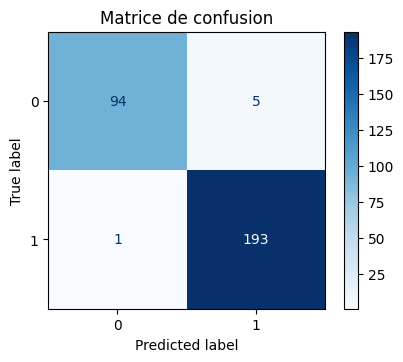


Tableau comparatif des métriques (avec focus sur la détection des faux billets) :
                                       Exactitude    Précision       Rappel  \
Régression Logistique                 0.989761092  1.000000000  0.969696970   
Régression Logistique + GridSearchCV  0.986348123  0.989690722  0.969696970   
Régression Logistique + Oversampling  0.982935154  0.979591837  0.969696970   
KMeans                                0.979522184  0.989473684  0.949494949   

                                         F1-Score  
Régression Logistique                 0.984615385  
Régression Logistique + GridSearchCV  0.979591837  
Régression Logistique + Oversampling  1.000000000  
KMeans                                0.969072165  


In [96]:
# Prédictions sur l'ensemble d'entraînement
train_clusters = clustering.predict(X_train_proj)

# Mapper les clusters prédits aux classes réelles à l'aide du mapping obtenu
y_train_pred = np.vectorize(cluster_mapping_1.get)(train_clusters)

# Évaluation des performances sur l'ensemble d'entraînement
train_accuracy = accuracy_score(y_train, y_train_pred)
train_confusion = confusion_matrix(y_train, y_train_pred)
train_classification = classification_report(y_train, y_train_pred)

print('Performance sur la base apprentissage')
print('Train Accuracy : ', train_accuracy)
print('Train Confusion matrix : \n', train_confusion)
print('Train Classification report : \n', train_classification)

# Prédictions sur l'ensemble de test
test_clusters = clustering.predict(X_test_proj)

# Mapper les clusters prédits aux classes réelles à l'aide du mapping obtenu
y_test_pred = np.vectorize(cluster_mapping_1.get)(test_clusters)

# Évaluation des performances sur l'ensemble de test
print('Performance sur la base test')
test_accuracy = accuracy_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
test_classification = classification_report(y_test, y_test_pred)

print('Test Accuracy : ', test_accuracy)
# print('Test Confusion matrix : \n', test_confusion)
print('Test Classification report : \n', test_classification)

# Affichage de la matrice de confusion pour le modèle
fig, ax = plt.subplots(figsize=(4.8, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap='Blues')
ax.set_title("Matrice de confusion")
plt.show()

# Calcul des métriques ciblées sur la classe "0" (faux billets)
# Nous extrayons les métriques pour la classe 0 à partir des fonctions de scoring
precision_counterfeit = round(precision_score(y_test, y_test_pred, pos_label=0), 9)
recall_counterfeit = round(recall_score(y_test, y_test_pred, pos_label=0), 9)
f1_counterfeit = round(f1_score(y_test, y_test_pred, pos_label=0), 9)

# Construction d'un DataFrame des résultats (arrondis à 9 décimales)
new_row = pd.DataFrame({
    "Exactitude": [f"{test_accuracy:.9f}"],
    "Précision": [f"{precision_counterfeit:.9f}"],
    "Rappel": [f"{recall_counterfeit:.9f}"],
    "F1-Score": [f"{f1_counterfeit:.9f}"]
}, index=["KMeans"])

# Utilisation de pd.concat() pour ajouter la nouvelle ligne
df_results = pd.concat([df_results, new_row], ignore_index=False)

print("\nTableau comparatif des métriques (avec focus sur la détection des faux billets) :")
print(df_results)

# KNN + GridSearchCV

K-Nearest Neighbors (KNN) est un type d'apprentissage supervisé qui peut être utilisé pour la classification et la régression. KNN fonctionne en trouvant   
les 'K' échantillons les plus proches dans l'ensemble de données d'apprentissage d'un nouvel échantillon non classé. L'échantillon non classé est ensuite classé   
basé sur la majorité des classes des 'K' échantillons les plus proches.

* **Étape 1: Choisir le nombre K de voisins**  
  La première étape de l'utilisation de l'algorithme KNN est de choisir le nombre 'K' de voisins. Il s'agit du nombre de voisins que nous examinerons  
  pour déterminer la classification d'un point de données non classé.

* **Étape 2: Calculer les distances euclidiennes**  
  Après avoir choisi un 'K', calculez la distance entre le point de données à classer et les autres points de données. La distance euclidienne est généralement  
  utilisée pour cela, mais d'autres mesures de distance comme la distance de Manhattan peuvent aussi être utilisées.

* **Étape 3: Trouver les K voisins les plus proches**  
  Trouver les 'K' points de données dans notre ensemble de données d'entraînement qui sont les plus proches du point de données que nous essayons de classer.

* **Étape 4: Voter pour la classe majoritaire**  
  Une fois que nous avons identifié les 'K' voisins les plus proches, nous les utilisons pour voter pour la classe du point de données non classé. Le point de données  
  non classé est généralement attribué à la classe qui a le plus de voisins parmi les 'K' voisins les plus proches.

* **Étape 5: Classer le point de données non classé**  
  En fonction du vote majoritaire des 'K' voisins, nous classons le point de données non classé.

Répétez les étapes 2 à 5 pour chaque point de données non classé dans l'ensemble de test.  

Il faut noter que l'algorithme KNN est un algorithme "paresseux" ce qui signifie qu'il ne construit pas un modèle utilisant l'ensemble d'apprentissage avant de faire  
des prédictions. Il fait des calculs au moment de faire des prédictions. Il peut donc être coûteux en temps et en ressources pour les grands ensembles de données.

In [97]:
# Définir les variables explicatives pour la classification.
# Ici, nous utilisons les 9 dimensions géométriques, y compris margin_low (qui est désormais complétée).
features_classif = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

# Définir la cible
target = "is_genuine"

# Création des ensembles X et y
X = df[features_classif]
y = df[target]

# Séparation en ensembles d'entraînement et de test (stratification pour respecter la répartition des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Liste des valeurs de k à tester
k_values = list(range(1, 30))



In [98]:
# Création de l'instance du classificateur KNN
knn = KNeighborsClassifier()
# Paramètres pour la recherche de grille
param_grid = {'n_neighbors': k_values}

# Recherche de grille avec validation croisée
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Extraction des scores de validation croisée et des valeurs de k correspondantes
cv_scores = grid_search.cv_results_['mean_test_score']
best_k = grid_search.best_params_['n_neighbors']

In [99]:
best_k

5

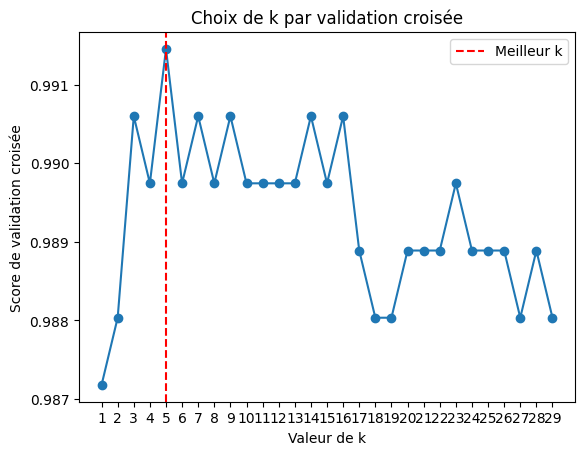

In [100]:
# Tracé du graphique des scores de validation croisée en fonction de k
plt.plot(k_values, cv_scores, '-o')
plt.xlabel('Valeur de k')
plt.ylabel('Score de validation croisée')
plt.title('Choix de k par validation croisée')
plt.xticks(k_values)
plt.axvline(x=best_k, color='r', linestyle='--', label='Meilleur k')
plt.legend()
plt.show()

Performance sur la base apprentissage
Train Accuracy :  0.9931623931623932
Train Confusion matrix : 
 [[387   6]
 [  2 775]]
Train Classification report : 
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       393
           1       0.99      1.00      0.99       777

    accuracy                           0.99      1170
   macro avg       0.99      0.99      0.99      1170
weighted avg       0.99      0.99      0.99      1170

Performance sur la base test
Test Accuracy :  0.9897610921501706
Test Classification report : 
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        99
           1       0.98      1.00      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.98      0.99       293
weighted avg       0.99      0.99      0.99       293



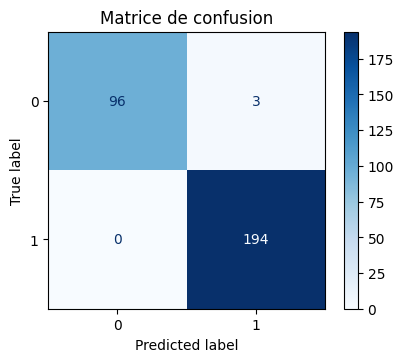


Tableau comparatif des métriques (avec focus sur la détection des faux billets) :
                                       Exactitude    Précision       Rappel  \
Régression Logistique                 0.989761092  1.000000000  0.969696970   
Régression Logistique + GridSearchCV  0.986348123  0.989690722  0.969696970   
Régression Logistique + Oversampling  0.982935154  0.979591837  0.969696970   
KMeans                                0.979522184  0.989473684  0.949494949   
KNN + GridSearchCV                    0.989761092  1.000000000  0.969696970   

                                         F1-Score  
Régression Logistique                 0.984615385  
Régression Logistique + GridSearchCV  0.979591837  
Régression Logistique + Oversampling  1.000000000  
KMeans                                0.969072165  
KNN + GridSearchCV                    0.984615385  


In [101]:
# Récupération du meilleur modèle optimisé
best_model=grid_search.best_estimator_

# Prédictions sur l'ensemble d'entraînement
y_train_pred = best_model.predict(X_train)

# Évaluation des performances sur l'ensemble d'entraînement
train_accuracy = accuracy_score(y_train, y_train_pred)
train_confusion = confusion_matrix(y_train, y_train_pred)
train_classification = classification_report(y_train, y_train_pred)

print('Performance sur la base apprentissage')
print('Train Accuracy : ', train_accuracy)
print('Train Confusion matrix : \n', train_confusion)
print('Train Classification report : \n', train_classification)

# Prédictions sur l'ensemble de test
y_test_pred = best_model.predict(X_test)

# Évaluation des performances sur l'ensemble de test
print('Performance sur la base test')
test_accuracy = accuracy_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
test_classification = classification_report(y_test, y_test_pred)

print('Test Accuracy : ', test_accuracy)
# print('Test Confusion matrix : \n', test_confusion)
print('Test Classification report : \n', test_classification)

# Affichage de la matrice de confusion pour le modèle
fig, ax = plt.subplots(figsize=(4.8, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap='Blues')
ax.set_title("Matrice de confusion")
plt.show()

# Calcul des métriques ciblées sur la classe "0" (faux billets)
# Nous extrayons les métriques pour la classe 0 à partir des fonctions de scoring
precision_counterfeit = round(precision_score(y_test, y_test_pred, pos_label=0), 9)
recall_counterfeit = round(recall_score(y_test, y_test_pred, pos_label=0), 9)
f1_counterfeit = round(f1_score(y_test, y_test_pred, pos_label=0), 9)

# Construction d'un DataFrame des résultats (arrondis à 9 décimales)
new_row = pd.DataFrame({
    "Exactitude": [f"{test_accuracy:.9f}"],
    "Précision": [f"{precision_counterfeit:.9f}"],
    "Rappel": [f"{recall_counterfeit:.9f}"],
    "F1-Score": [f"{f1_counterfeit:.9f}"]
}, index=["KNN + GridSearchCV"])

# Utilisation de pd.concat() pour ajouter la nouvelle ligne
df_results = pd.concat([df_results, new_row], ignore_index=False)

print("\nTableau comparatif des métriques (avec focus sur la détection des faux billets) :")
print(df_results)

# Decision Tree

L'arbre de décision est une méthode d'apprentissage supervisé utilisée pour la classification et la régression. L'objectif est de créer un modèle qui prédit  
la valeur d'une variable cible en apprenant des règles de décision simples déduites des caractéristiques des données. Une série de décisions séquentielles (« si-alors-sinon »)  
sont prises en fonction des caractéristiques des données créant ainsi une structure en arboresence.

In [102]:
# Définir les variables explicatives pour la classification.
# Ici, nous utilisons les 9 dimensions géométriques, y compris margin_low (qui est désormais complétée).
features_classif = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

# Définir la cible
target = "is_genuine"

# Création des ensembles X et y
X = df[features_classif]
y = df[target]

# Séparation en ensembles d'entraînement et de test (stratification pour respecter la répartition des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [103]:
# Construction de l'arbre de décision
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

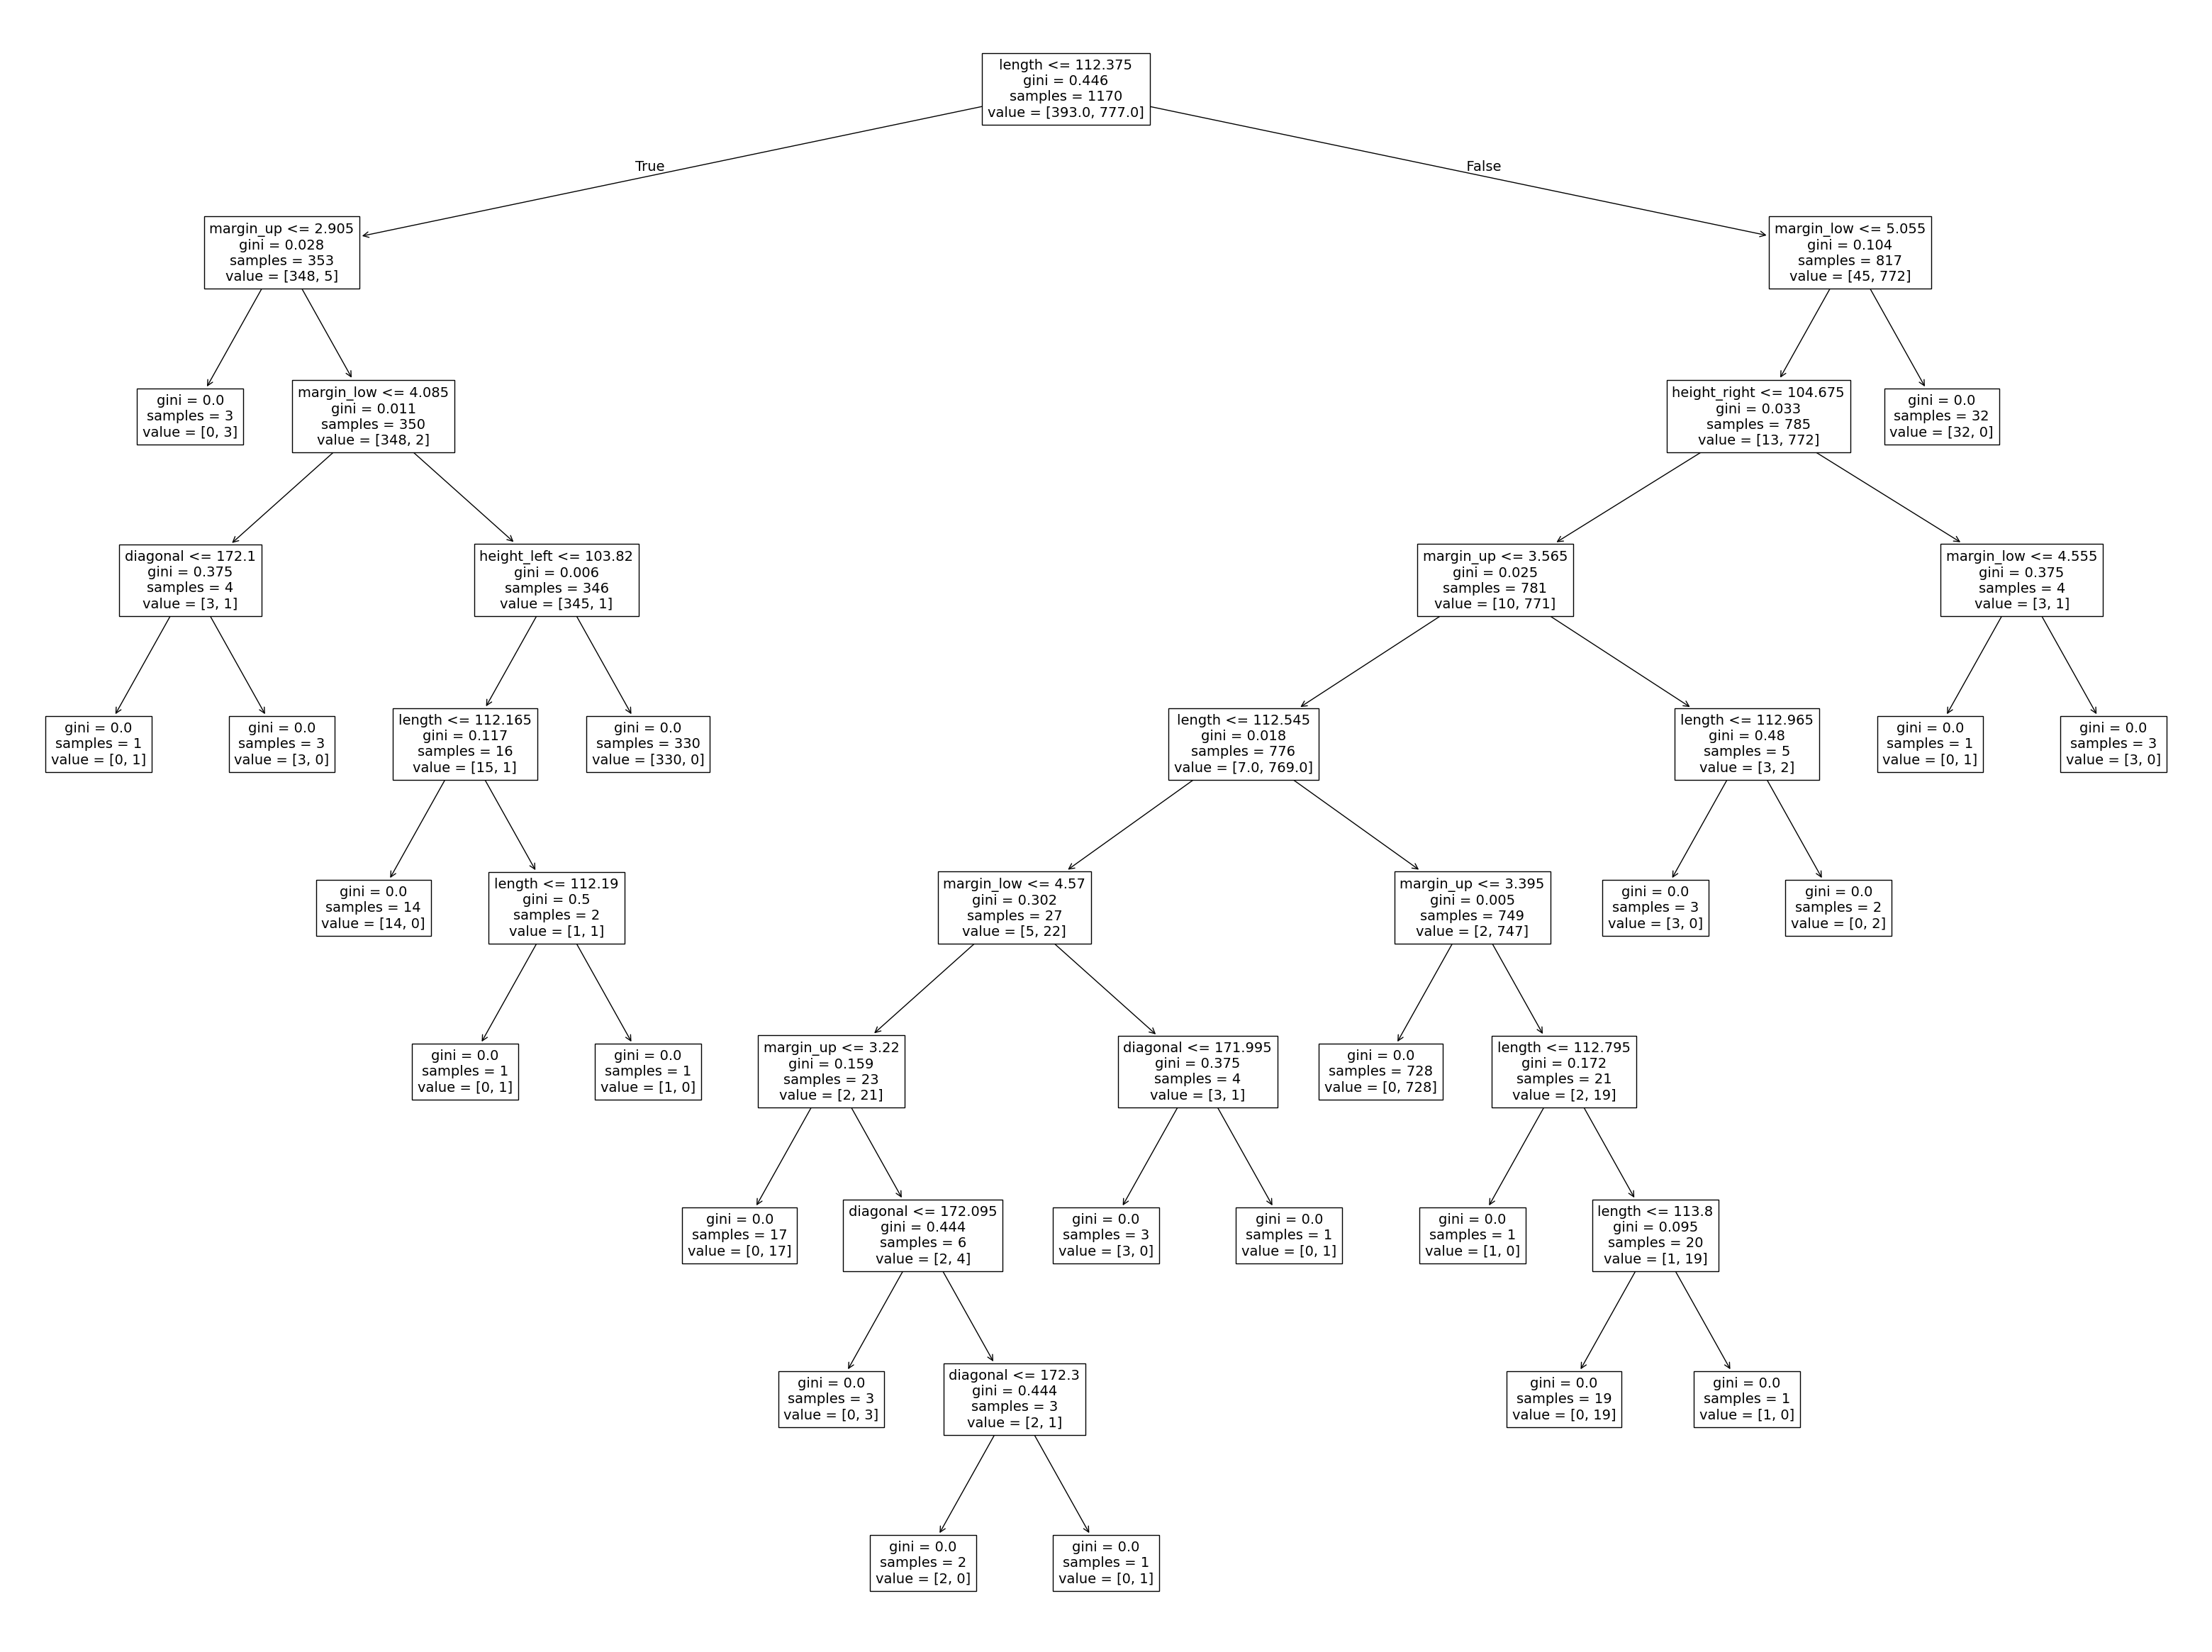

In [104]:
# Visualisation de l'arbre
plt.figure(figsize=(40,30))
plot_tree(tree, feature_names=X.columns)
plt.show()

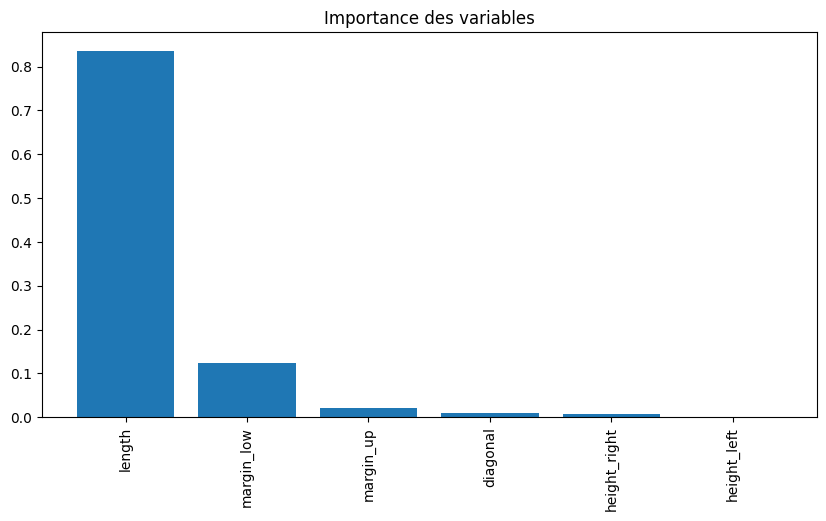

In [105]:
# Affichage de l'importance des variables
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Importance des variables")
plt.bar(range(X_train.shape[1]), importances[indices])
plt.xticks(range(X_train.shape[1]), X.columns[indices], rotation=90)
plt.show()

Performance sur la base apprentissage
Train Accuracy :  1.0
Train Confusion matrix : 
 [[393   0]
 [  0 777]]
Train Classification report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       393
           1       1.00      1.00      1.00       777

    accuracy                           1.00      1170
   macro avg       1.00      1.00      1.00      1170
weighted avg       1.00      1.00      1.00      1170

Performance sur la base test
Test Accuracy :  0.9829351535836177
Test Classification report : 
               precision    recall  f1-score   support

           0       0.99      0.96      0.97        99
           1       0.98      0.99      0.99       194

    accuracy                           0.98       293
   macro avg       0.98      0.98      0.98       293
weighted avg       0.98      0.98      0.98       293



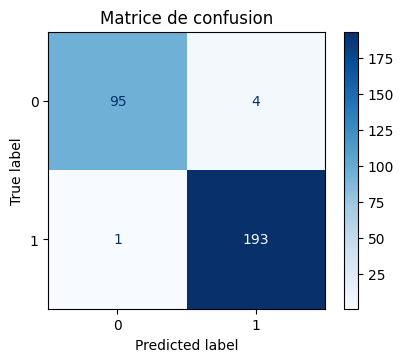


Tableau comparatif des métriques (avec focus sur la détection des faux billets) :
                                       Exactitude    Précision       Rappel  \
Régression Logistique                 0.989761092  1.000000000  0.969696970   
Régression Logistique + GridSearchCV  0.986348123  0.989690722  0.969696970   
Régression Logistique + Oversampling  0.982935154  0.979591837  0.969696970   
KMeans                                0.979522184  0.989473684  0.949494949   
KNN + GridSearchCV                    0.989761092  1.000000000  0.969696970   
Decision Tree                         0.982935154  0.989583333  0.959595960   

                                         F1-Score  
Régression Logistique                 0.984615385  
Régression Logistique + GridSearchCV  0.979591837  
Régression Logistique + Oversampling  1.000000000  
KMeans                                0.969072165  
KNN + GridSearchCV                    0.984615385  
Decision Tree                         0.974358974  

In [106]:
# Prédictions sur l'ensemble d'entraînement
y_train_pred = tree.predict(X_train)

# Évaluation des performances sur l'ensemble d'entraînement
train_accuracy = accuracy_score(y_train, y_train_pred)
train_confusion = confusion_matrix(y_train, y_train_pred)
train_classification = classification_report(y_train, y_train_pred)

print('Performance sur la base apprentissage')
print('Train Accuracy : ', train_accuracy)
print('Train Confusion matrix : \n', train_confusion)
print('Train Classification report : \n', train_classification)

# Prédictions sur l'ensemble de test
y_test_pred = tree.predict(X_test)

# Évaluation des performances sur l'ensemble de test
print('Performance sur la base test')
test_accuracy = accuracy_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
test_classification = classification_report(y_test, y_test_pred)

print('Test Accuracy : ', test_accuracy)
# print('Test Confusion matrix : \n', test_confusion)
print('Test Classification report : \n', test_classification)

# Affichage de la matrice de confusion pour le modèle
fig, ax = plt.subplots(figsize=(4.8, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap='Blues')
ax.set_title("Matrice de confusion")
plt.show()

# Calcul des métriques ciblées sur la classe "0" (faux billets)
# Nous extrayons les métriques pour la classe 0 à partir des fonctions de scoring
precision_counterfeit = round(precision_score(y_test, y_test_pred, pos_label=0), 9)
recall_counterfeit = round(recall_score(y_test, y_test_pred, pos_label=0), 9)
f1_counterfeit = round(f1_score(y_test, y_test_pred, pos_label=0), 9)

# Construction d'un DataFrame des résultats (arrondis à 9 décimales)
new_row = pd.DataFrame({
    "Exactitude": [f"{test_accuracy:.9f}"],
    "Précision": [f"{precision_counterfeit:.9f}"],
    "Rappel": [f"{recall_counterfeit:.9f}"],
    "F1-Score": [f"{f1_counterfeit:.9f}"]
}, index=["Decision Tree"])

# Utilisation de pd.concat() pour ajouter la nouvelle ligne
df_results = pd.concat([df_results, new_row], ignore_index=False)

print("\nTableau comparatif des métriques (avec focus sur la détection des faux billets) :")
print(df_results)

En parcourant notre arbre de décision nous pouvons remarquer qu'il est complexe.
Il ne généralise pas bien les données et ses résultats sur les données d'entraînement nous amène à la conclusion qu'il fait du surapprentissage.  
Nous allons définir la profondeur maximale de l'arbre nécessaire pour éviter ce problème.

#### Optimisation avec une validation croisée

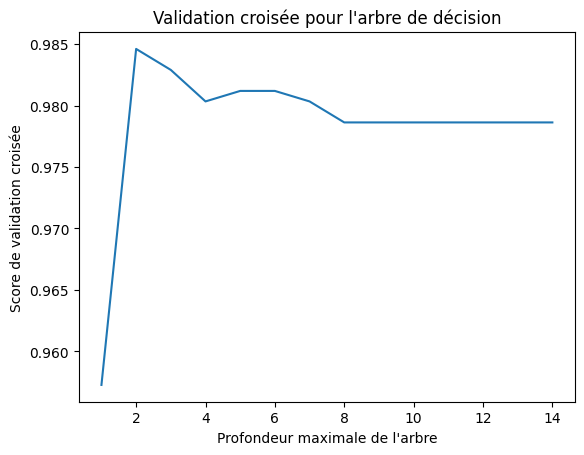

In [107]:
# Liste des profondeurs maximales à tester
max_depths = range(1, 15)

# Liste pour stocker les scores de validation croisée
cv_scores = []

# Pour chaque profondeur maximale, entraîner un arbre de décision et calculer le score de validation croisée
for depth in max_depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(tree, X_train, y_train, cv=10)
    cv_scores.append(np.mean(scores))

# Tracer le graphique de validation croisée pour choisir la complexité de l'arbre optimal
plt.plot(max_depths, cv_scores)
plt.xlabel('Profondeur maximale de l\'arbre')
plt.ylabel('Score de validation croisée')
plt.title('Validation croisée pour l\'arbre de décision')
plt.show()

In [108]:
# Trouver la profondeur maximale qui donne le meilleur score de validation croisée
best_depth = max_depths[np.argmax(cv_scores)]
print('La meilleure profondeur maximale est :', best_depth)

La meilleure profondeur maximale est : 2


In [109]:
# Construire l'arbre de décision avec la profondeur maximale choisie
tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

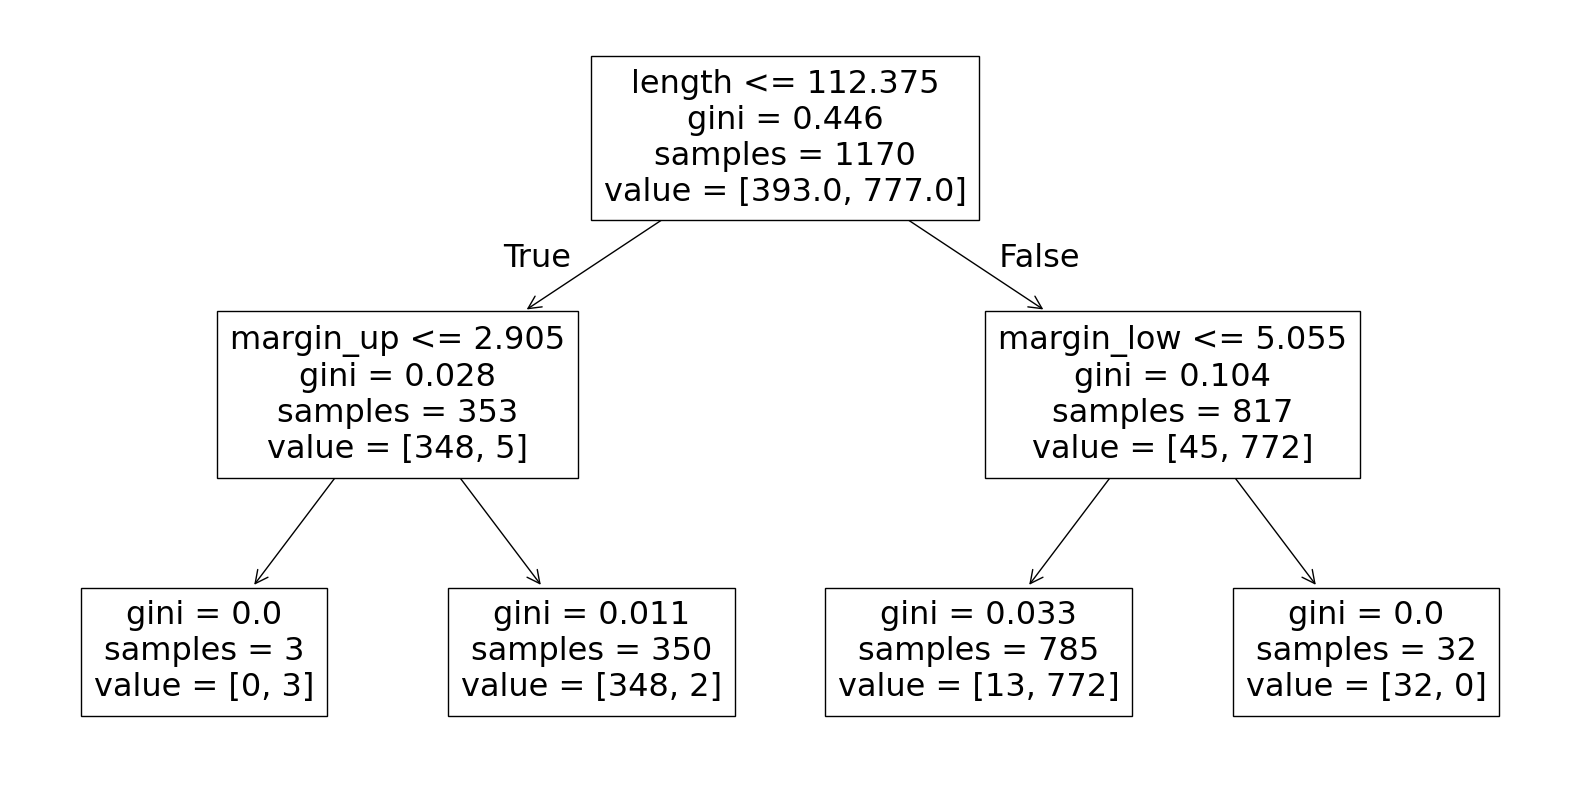

In [110]:
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns)
plt.show()

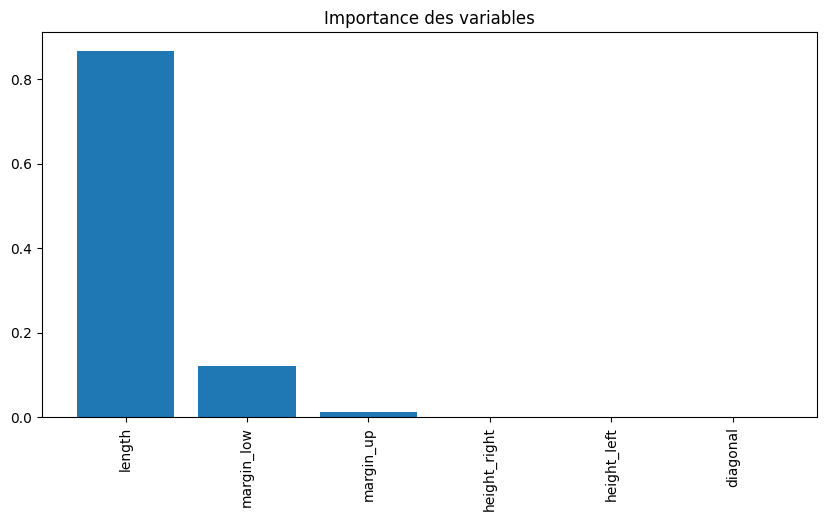

In [111]:
# Affichage de l'importance des variables
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Importance des variables")
plt.bar(range(X_train.shape[1]), importances[indices])
plt.xticks(range(X_train.shape[1]), X.columns[indices], rotation=90)
plt.show()

Performance sur la base apprentissage
Train Accuracy :  0.9871794871794872
Train Confusion matrix : 
 [[380  13]
 [  2 775]]
Train Classification report : 
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       393
           1       0.98      1.00      0.99       777

    accuracy                           0.99      1170
   macro avg       0.99      0.98      0.99      1170
weighted avg       0.99      0.99      0.99      1170

Performance sur la base test
Test Accuracy :  0.9829351535836177
Test Classification report : 
               precision    recall  f1-score   support

           0       0.99      0.96      0.97        99
           1       0.98      0.99      0.99       194

    accuracy                           0.98       293
   macro avg       0.98      0.98      0.98       293
weighted avg       0.98      0.98      0.98       293



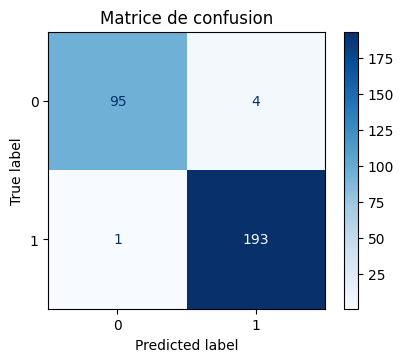


Tableau comparatif des métriques (avec focus sur la détection des faux billets) :
                                       Exactitude    Précision       Rappel  \
Régression Logistique                 0.989761092  1.000000000  0.969696970   
Régression Logistique + GridSearchCV  0.986348123  0.989690722  0.969696970   
Régression Logistique + Oversampling  0.982935154  0.979591837  0.969696970   
KMeans                                0.979522184  0.989473684  0.949494949   
KNN + GridSearchCV                    0.989761092  1.000000000  0.969696970   
Decision Tree                         0.982935154  0.989583333  0.959595960   
Decision Tree optimisé                0.982935154  0.989583333  0.959595960   

                                         F1-Score  
Régression Logistique                 0.984615385  
Régression Logistique + GridSearchCV  0.979591837  
Régression Logistique + Oversampling  1.000000000  
KMeans                                0.969072165  
KNN + GridSearchCV      

In [112]:
# Prédictions sur l'ensemble d'entraînement
y_train_pred = tree.predict(X_train)

# Évaluation des performances sur l'ensemble d'entraînement
train_accuracy = accuracy_score(y_train, y_train_pred)
train_confusion = confusion_matrix(y_train, y_train_pred)
train_classification = classification_report(y_train, y_train_pred)

print('Performance sur la base apprentissage')
print('Train Accuracy : ', train_accuracy)
print('Train Confusion matrix : \n', train_confusion)
print('Train Classification report : \n', train_classification)

# Prédictions sur l'ensemble de test
y_test_pred = tree.predict(X_test)

# Évaluation des performances sur l'ensemble de test
print('Performance sur la base test')
test_accuracy = accuracy_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
test_classification = classification_report(y_test, y_test_pred)

print('Test Accuracy : ', test_accuracy)
# print('Test Confusion matrix : \n', test_confusion)
print('Test Classification report : \n', test_classification)

# Affichage de la matrice de confusion pour le modèle
fig, ax = plt.subplots(figsize=(4.8, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap='Blues')
ax.set_title("Matrice de confusion")
plt.show()

# Calcul des métriques ciblées sur la classe "0" (faux billets)
# Nous extrayons les métriques pour la classe 0 à partir des fonctions de scoring
precision_counterfeit = round(precision_score(y_test, y_test_pred, pos_label=0), 9)
recall_counterfeit = round(recall_score(y_test, y_test_pred, pos_label=0), 9)
f1_counterfeit = round(f1_score(y_test, y_test_pred, pos_label=0), 9)

# Construction d'un DataFrame des résultats (arrondis à 9 décimales)
new_row = pd.DataFrame({
    "Exactitude": [f"{test_accuracy:.9f}"],
    "Précision": [f"{precision_counterfeit:.9f}"],
    "Rappel": [f"{recall_counterfeit:.9f}"],
    "F1-Score": [f"{f1_counterfeit:.9f}"]
}, index=["Decision Tree optimisé"])

# Utilisation de pd.concat() pour ajouter la nouvelle ligne
df_results = pd.concat([df_results, new_row], ignore_index=False)

print("\nTableau comparatif des métriques (avec focus sur la détection des faux billets) :")
print(df_results)

# Random Forest

La forêt aléatoire est un algorithme d’apprentissage supervisé qui compile les résultats de plusieurs arbres de décision formés de manière alétaoire.

Performance sur la base apprentissage
Train Accuracy :  1.0
Train Confusion matrix : 
 [[393   0]
 [  0 777]]
Train Classification report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       393
           1       1.00      1.00      1.00       777

    accuracy                           1.00      1170
   macro avg       1.00      1.00      1.00      1170
weighted avg       1.00      1.00      1.00      1170

Performance sur la base test
Test Accuracy :  0.9897610921501706
Test Classification report : 
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        99
           1       0.98      1.00      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.98      0.99       293
weighted avg       0.99      0.99      0.99       293



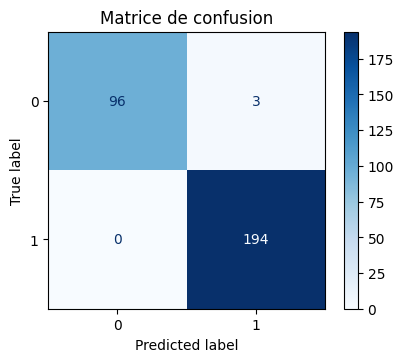


Tableau comparatif des métriques (avec focus sur la détection des faux billets) :
                                       Exactitude    Précision       Rappel  \
Régression Logistique                 0.989761092  1.000000000  0.969696970   
Régression Logistique + GridSearchCV  0.986348123  0.989690722  0.969696970   
Régression Logistique + Oversampling  0.982935154  0.979591837  0.969696970   
KMeans                                0.979522184  0.989473684  0.949494949   
KNN + GridSearchCV                    0.989761092  1.000000000  0.969696970   
Decision Tree                         0.982935154  0.989583333  0.959595960   
Decision Tree optimisé                0.982935154  0.989583333  0.959595960   
Random Forest                         0.989761092  1.000000000  0.969696970   

                                         F1-Score  
Régression Logistique                 0.984615385  
Régression Logistique + GridSearchCV  0.979591837  
Régression Logistique + Oversampling  1.000000000

In [113]:
# Initialisation du modèle Random Forest
rf = RandomForestClassifier(oob_score=True)

# Entraînement du modèle sur l'ensemble d'entraînement
rf.fit(X_train, y_train)

# Prédictions sur l'ensemble d'entraînement
y_train_pred = rf.predict(X_train)

# Évaluation des performances sur l'ensemble d'entraînement
train_accuracy = accuracy_score(y_train, y_train_pred)
train_confusion = confusion_matrix(y_train, y_train_pred)
train_classification = classification_report(y_train, y_train_pred)

print('Performance sur la base apprentissage')
print('Train Accuracy : ', train_accuracy)
print('Train Confusion matrix : \n', train_confusion)
print('Train Classification report : \n', train_classification)

# Prédictions sur l'ensemble de test
y_test_pred = rf.predict(X_test)

# Évaluation des performances sur l'ensemble de test
print('Performance sur la base test')
test_accuracy = accuracy_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
test_classification = classification_report(y_test, y_test_pred)

print('Test Accuracy : ', test_accuracy)
# print('Test Confusion matrix : \n', test_confusion)
print('Test Classification report : \n', test_classification)

# Affichage de la matrice de confusion pour le modèle
fig, ax = plt.subplots(figsize=(4.8, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap='Blues')
ax.set_title("Matrice de confusion")
plt.show()

# Calcul des métriques ciblées sur la classe "0" (faux billets)
# Nous extrayons les métriques pour la classe 0 à partir des fonctions de scoring
precision_counterfeit = round(precision_score(y_test, y_test_pred, pos_label=0), 9)
recall_counterfeit = round(recall_score(y_test, y_test_pred, pos_label=0), 9)
f1_counterfeit = round(f1_score(y_test, y_test_pred, pos_label=0), 9)

# Construction d'un DataFrame des résultats (arrondis à 9 décimales)
new_row = pd.DataFrame({
    "Exactitude": [f"{test_accuracy:.9f}"],
    "Précision": [f"{precision_counterfeit:.9f}"],
    "Rappel": [f"{recall_counterfeit:.9f}"],
    "F1-Score": [f"{f1_counterfeit:.9f}"]
}, index=["Random Forest"])

# Utilisation de pd.concat() pour ajouter la nouvelle ligne
df_results = pd.concat([df_results, new_row], ignore_index=False)

print("\nTableau comparatif des métriques (avec focus sur la détection des faux billets) :")
print(df_results)

Les résultats des données d'entraînement nous indique que ce modèle fait du surapprentissage.  
Nous devons donc l'optimiser avec GridSearchCV via une validation croisée.

#### Optimisation avec `GridSearchCV`

Certains paramètres sont essentiels à optimiser pour obtenir de bonnes performances du modèle. Voici les paramètres les plus importants à prendre en compte :

- n_estimators : Il s'agit du nombre d'arbres de décision dans la forêt aléatoire. Augmenter ce nombre peut améliorer les performances du modèle, mais cela entraîne  
  également une augmentation du temps de calcul.

- max_depth : C'est la profondeur maximale de chaque arbre de décision. Une valeur plus élevée permet à l'arbre d'apprendre des relations plus complexes dans les données,  
  mais elle peut également conduire à un surajustement. Il est important de trouver un équilibre pour éviter l'overfitting.

- min_samples_split : Ce paramètre définit le nombre minimum d'échantillons requis pour scinder un nœud. Une valeur plus élevée peut conduire à des arbres plus simples et  
  éviter l'overfitting, mais cela peut également entraîner une sous-représentation des informations dans les données.

In [114]:
# Définir les hyperparamètres à tester à l'aide de GridSearch
param_grid = {
    'n_estimators': [100, 200, 300,500],
    'max_depth': [1,2,3,4,6,7,8]
}

# Créer un modèle de forêt aléatoire
rf_model = RandomForestClassifier(oob_score=True, random_state=42)

# Utiliser GridSearch pour trouver les meilleurs paramètres
grid_search = GridSearchCV(rf_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés
print("Meilleurs paramètres :", grid_search.best_params_)

Meilleurs paramètres : {'max_depth': 4, 'n_estimators': 500}


In [115]:
# Créer un modèle de forêt aléatoire avec les meilleurs paramètres
random_forest = RandomForestClassifier(n_estimators=grid_search.best_params_['n_estimators'], max_depth=grid_search.best_params_['max_depth'], oob_score=True, random_state=42)
# Entraîner le modèle sur les données d'entraînement
random_forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, n_estimators=500, oob_score=True,
                       random_state=42)

Performance sur la base apprentissage
Train Accuracy :  0.9948717948717949
Train Confusion matrix : 
 [[388   5]
 [  1 776]]
Train Classification report : 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       393
           1       0.99      1.00      1.00       777

    accuracy                           0.99      1170
   macro avg       1.00      0.99      0.99      1170
weighted avg       0.99      0.99      0.99      1170

Performance sur la base test
Test Accuracy :  0.9897610921501706
Test Classification report : 
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        99
           1       0.98      1.00      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.98      0.99       293
weighted avg       0.99      0.99      0.99       293



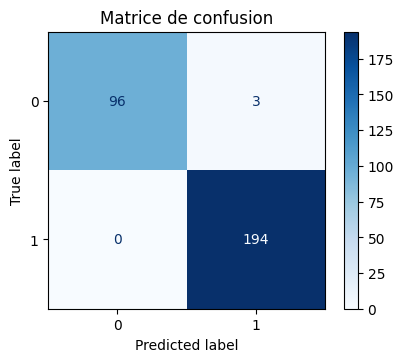


Tableau comparatif des métriques (avec focus sur la détection des faux billets) :
                                       Exactitude    Précision       Rappel  \
Régression Logistique                 0.989761092  1.000000000  0.969696970   
Régression Logistique + GridSearchCV  0.986348123  0.989690722  0.969696970   
Régression Logistique + Oversampling  0.982935154  0.979591837  0.969696970   
KMeans                                0.979522184  0.989473684  0.949494949   
KNN + GridSearchCV                    0.989761092  1.000000000  0.969696970   
Decision Tree                         0.982935154  0.989583333  0.959595960   
Decision Tree optimisé                0.982935154  0.989583333  0.959595960   
Random Forest                         0.989761092  1.000000000  0.969696970   
Random Forest + GridSearchCV          0.989761092  1.000000000  0.969696970   

                                         F1-Score  
Régression Logistique                 0.984615385  
Régression Logistique 

In [116]:
# Prédictions sur l'ensemble d'entraînement
y_train_pred = random_forest.predict(X_train)

# Évaluation des performances sur l'ensemble d'entraînement
train_accuracy = accuracy_score(y_train, y_train_pred)
train_confusion = confusion_matrix(y_train, y_train_pred)
train_classification = classification_report(y_train, y_train_pred)

print('Performance sur la base apprentissage')
print('Train Accuracy : ', train_accuracy)
print('Train Confusion matrix : \n', train_confusion)
print('Train Classification report : \n', train_classification)

# Prédictions sur l'ensemble de test
y_test_pred = random_forest.predict(X_test)

# Évaluation des performances sur l'ensemble de test
print('Performance sur la base test')
test_accuracy = accuracy_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
test_classification = classification_report(y_test, y_test_pred)

print('Test Accuracy : ', test_accuracy)
# print('Test Confusion matrix : \n', test_confusion)
print('Test Classification report : \n', test_classification)

# Affichage de la matrice de confusion pour le modèle
fig, ax = plt.subplots(figsize=(4.8, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, cmap='Blues')
ax.set_title("Matrice de confusion")
plt.show()

# Calcul des métriques ciblées sur la classe "0" (faux billets)
# Nous extrayons les métriques pour la classe 0 à partir des fonctions de scoring
precision_counterfeit = round(precision_score(y_test, y_test_pred, pos_label=0), 9)
recall_counterfeit = round(recall_score(y_test, y_test_pred, pos_label=0), 9)
f1_counterfeit = round(f1_score(y_test, y_test_pred, pos_label=0), 9)

# Construction d'un DataFrame des résultats (arrondis à 9 décimales)
new_row = pd.DataFrame({
    "Exactitude": [f"{test_accuracy:.9f}"],
    "Précision": [f"{precision_counterfeit:.9f}"],
    "Rappel": [f"{recall_counterfeit:.9f}"],
    "F1-Score": [f"{f1_counterfeit:.9f}"]
}, index=["Random Forest + GridSearchCV"])

# Utilisation de pd.concat() pour ajouter la nouvelle ligne
df_results = pd.concat([df_results, new_row], ignore_index=False)

print("\nTableau comparatif des métriques (avec focus sur la détection des faux billets) :")
print(df_results)

In [117]:
df_results


,Exactitude,Précision,Rappel,F1-Score
Régression Logistique,0.989761092,1.000000000,0.969696970,0.984615385
Régression Logistique + GridSearchCV,0.986348123,0.989690722,0.969696970,0.979591837
Régression Logistique + Oversampling,0.982935154,0.979591837,0.969696970,1.000000000
KMeans,0.979522184,0.989473684,0.949494949,0.969072165
KNN + GridSearchCV,0.989761092,1.000000000,0.969696970,0.984615385
Decision Tree,0.982935154,0.989583333,0.959595960,0.974358974
Decision Tree optimisé,0.982935154,0.989583333,0.959595960,0.974358974
Random Forest,0.989761092,1.000000000,0.969696970,0.984615385
Random Forest + GridSearchCV,0.989761092,1.000000000,0.969696970,0.984615385


# Choix de l'algorithme

In [118]:
import joblib

# Sauvegarder le modèle dans un fichier .pkl
joblib.dump(random_forest, 'random_forest_model.pkl')
print("Modèle sauvegardé sous 'random_forest_model.pkl'")


Modèle sauvegardé sous 'random_forest_model.pkl'
